# ExplainPhish: HTML Phishing Detection Tutorial
This NOTEBOOK provides a comprehensive end-to-end workflow for detecting phishing HTML documents using machine learning and explainable AI.

**Objective**: To predict whether an HTML document/attachment is Phishing (`1`) or Benign (`0`) based on static features extracted from the **CIC-Trap4Phish2025** benchmark.

**Evaluation metric**: ROC-AUC (Area Under the Receiver Operating Characteristic Curve) and Accuracy.

---

## Contents
- [1. Setup & Environment](#scrollTo=setup)
  - [1.1 Import Libraries](#scrollTo=import_libraries)
  - [1.2 Adaptive Path Resolution](#scrollTo=path_config)
- [2. Loading the Data & Data Overview](#scrollTo=loading_data)
  - [2.1 Raw Loading](#scrollTo=raw_loading)
  - [2.2 Data Cleaning & Artifact Removal](#scrollTo=data_cleaning)
  - [2.3 Feature Inventory & Data Types](#scrollTo=feature_inventory)
  - [2.4 Summary & Descriptive Statistics](#scrollTo=descriptive_stats)
  - [2.5 Target Class Balance Analysis](#scrollTo=class_balance)
  - [2.6 HTML Feature Definitions & Threat Relevance](#scrollTo=feature_definitions)
- [3. Visualizing and Understanding the Data](#scrollTo=sec3)
  - [3.1 Checking Missing Values](#scrollTo=sec3_1)
  - [3.2 Visualization and Analysis of Each Feature (Distribution Evenness)](#scrollTo=sec3_2)
    - [3.2.1 Skewness & Distribution Evenness Assessment](#scrollTo=sec3_2_1)
    - [3.2.2 Full Feature Distribution Overview (Grid Visualization)](#scrollTo=sec3_2_2)
    - [3.2.3 TARGET Column (Class Evenness)](#scrollTo=sec3_2_3)
    - [3.2.4 Evenly Distributed Attributes (Entropy & Whitespace Ratios)](#scrollTo=sec3_2_4)
    - [3.2.5 Heavy-Tailed Attributes: Raw vs. Logarithmic Transformation](#scrollTo=sec3_2_5)
    - [3.2.6 URL & Navigation Link Attributes](#scrollTo=sec3_2_6)
    - [3.2.7 Comprehensive Evenness & Distribution Summary Table](#scrollTo=sec3_2_7)
  - [3.3 Summary Findings & Next Steps](#scrollTo=sec3_3)
- [4. Preprocessing and Feature Creation](#scrollTo=sec4)
- [5. Building the Machine Learning Model](#scrollTo=sec5)
  - [5.1 Import Additional Libraries](#scrollTo=sec5_1)
  - [5.2 Preparing the Data & Standardization](#scrollTo=sec5_2)
  - [5.3 Training the Model (Holdout 70/30 Validation)](#scrollTo=sec5_3)
  - [5.4 Visualizations for Random Forest, Decision Tree & Logistic Regression](#scrollTo=sec5_4)
    - [5.4.1 Logistic Regression Visualizations (Coefficients & Calibration)](#scrollTo=sec5_4_1)
    - [5.4.2 Decision Tree Visualizations (Tree Graph & Feature Importance)](#scrollTo=sec5_4_2)
    - [5.4.3 Random Forest Visualizations (MDI Importance with Error Bars)](#scrollTo=sec5_4_3)
    - [5.4.4 Multi-Model Comparison (ROC Curves, Confusion Matrices, Metrics)](#scrollTo=sec5_4_4)
  - [5.5 (Optional) Use Voting Learning of 3 Different Models](#scrollTo=sec5_5)
  - [5.6 Saving Models into One Folder for Multimodal Voting (InterfaceExplainPhish)](#scrollTo=sec5_6)
- [6. Creating Prediction Results](#scrollTo=sec6)
  - [6.1 Predicting on the Test Data](#scrollTo=sec6_1)
  - [6.2 Saving the Prediction as CSV File [DO NOT CHANGE]](#scrollTo=sec6_2)


<a name="setup"></a>
## 1. Setup & Environment

In this section, we set up the environment, import standard data science and visualization libraries with consistent visual themes, and locate the dataset file.

<a name="import_libraries"></a>
### 1.1 Import Libraries
We import `pandas` for tabular data manipulation, `numpy` for numerical calculations, `matplotlib` and `seaborn` for visualizations, and `pathlib` for flexible cross-platform path resolution.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

print("Environment configured successfully with consistent visual theme!")

Environment configured successfully with consistent visual theme!


<a name="path_config"></a>
### 1.2 Adaptive Path Resolution
To ensure this notebook runs seamlessly whether executed locally in VS Code / Jupyter, from the repository root, or in Google Colab (with or without Google Drive mounted), we define adaptive path resolution for `HTML_Top13_Features.csv`.

In [2]:
# Adaptive path detection for local environments and Google Colab
candidates = [
    Path("data/html/HTML_Top13_Features.csv"),
    Path("googleCollab/data/html/HTML_Top13_Features.csv"),
    Path("../data/html/HTML_Top13_Features.csv"),
    Path("../googleCollab/data/html/HTML_Top13_Features.csv"),
    Path("../../googleCollab/data/html/HTML_Top13_Features.csv"),
    Path("/content/drive/MyDrive/ExplainPhish/data/html/HTML_Top13_Features.csv"),
    Path("/content/drive/MyDrive/ExplainPhish/googleCollab/data/html/HTML_Top13_Features.csv"),
    Path("/content/HTML_Top13_Features.csv")
]

dataset_path = None
for p in candidates:
    if p.exists():
        dataset_path = p
        break

if dataset_path is not None:
    print(f"Dataset located successfully at:\n{dataset_path.resolve()}")
else:
    raise FileNotFoundError(
        "Could not automatically locate 'HTML_Top13_Features.csv'. "
        "Please upload the file to Google Colab or verify the directory path."
    )

Dataset located successfully at:
D:\codingProject\ExplainPhish\googleCollab\data\html\HTML_Top13_Features.csv


<a name="loading_data"></a>
## 2. Loading the Data & Data Overview

In this section, we load the raw HTML feature table, sanitize export artifacts, examine dataset dimensions, inspect column types, evaluate summary statistics, evaluate class balance, and review the security relevance of each feature.

<a name="raw_loading"></a>
### 2.1 Raw Loading
We load the raw CSV file into a `pandas.DataFrame` and preview the first 5 records.

In [3]:
# Load raw dataset
raw_df = pd.read_csv(dataset_path)

print(f"Raw Dataset Dimensions: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
raw_df.head(5)

Raw Dataset Dimensions: 19,997 rows x 27 columns


,file_name,url_punct_char_count,tag_count,whitespace_ratio,entropy,form_count,embedded_js_count,html_whitespace_ratio,script_entropy,min_link_length,external_link_count,total_script_characters,internal_link_count,url_digit_count,label,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26
0,sample_09001.html,756,475,0.4769,5.0729,0,11,0.1527,4.9064,1,57,15762,39,109,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sample_09002.html,287,82,0.3566,5.2020,0,3,0.1795,4.6251,21,8,2543,27,130,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sample_09003.html,667,406,0.3902,5.1642,1,10,0.1498,4.2204,9,80,7163,26,333,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sample_09004.html,1204,321,0.5348,5.6712,0,33,0.0257,5.6267,17,74,268250,2,1013,0,NaN,NaN,NaN,9998.0000,NaN,NaN,NaN,NaN,9998.0000,NaN,NaN,NaN
4,sample_09005.html,2606,665,0.4416,5.1366,5,8,0.1301,5.4630,8,243,7666,8,924,0,NaN,NaN,NaN,10000.0000,NaN,19998.0000,9999.0000,NaN,10000.0000,NaN,19998.0000,11998.8000


<a name="data_cleaning"></a>
### 2.2 Data Cleaning & Artifact Removal
Notice that the raw CSV file contains trailing `Unnamed: 15` through `Unnamed: 26` columns. These are empty artifacts caused by trailing delimiters during export. We identify and drop these empty columns, reducing the table to the sample identifier (`file_name`), 13 security features, and target label (`label`).

We also create the `TARGET` column mapped to `label` and partition the data into a **stratified 60% Train / 40% Test split** (11,998 train / 7,999 test samples) matching the ExplainPhish methodology.

In [4]:
from sklearn.model_selection import train_test_split

# Identify trailing artifact columns
unnamed_cols = [c for c in raw_df.columns if "unnamed" in c.lower()]
print(f"Identified {len(unnamed_cols)} trailing artifact columns to drop: {unnamed_cols}")

# Drop artifact columns to produce clean dataframe
df = raw_df.drop(columns=unnamed_cols).copy()
df["TARGET"] = df["label"]

# Stratified 60% Train / 40% Test Split (aligned with ExplainPhish methodology)
train, test = train_test_split(
    df, test_size=0.40, stratify=df["TARGET"], random_state=42
)
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

print(f"Cleaned Dataset Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Train split: {train.shape[0]:,} rows | Test split: {test.shape[0]:,} rows")
df.head(5)

Identified 12 trailing artifact columns to drop: ['Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26']
Cleaned Dataset Dimensions: 19,997 rows x 16 columns
Train split: 11,998 rows | Test split: 7,999 rows


,file_name,url_punct_char_count,tag_count,whitespace_ratio,entropy,form_count,embedded_js_count,html_whitespace_ratio,script_entropy,min_link_length,external_link_count,total_script_characters,internal_link_count,url_digit_count,label,TARGET
0,sample_09001.html,756,475,0.4769,5.0729,0,11,0.1527,4.9064,1,57,15762,39,109,0,0
1,sample_09002.html,287,82,0.3566,5.2020,0,3,0.1795,4.6251,21,8,2543,27,130,0,0
2,sample_09003.html,667,406,0.3902,5.1642,1,10,0.1498,4.2204,9,80,7163,26,333,0,0
3,sample_09004.html,1204,321,0.5348,5.6712,0,33,0.0257,5.6267,17,74,268250,2,1013,0,0
4,sample_09005.html,2606,665,0.4416,5.1366,5,8,0.1301,5.4630,8,243,7666,8,924,0,0


<a name="feature_inventory"></a>
### 2.3 Feature Inventory & Data Types
Let's inspect the data types, non-null counts, and memory footprint of the cleaned dataset.

In [5]:
# Inspect column data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19997 entries, 0 to 19996
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   file_name                19997 non-null  str    
 1   url_punct_char_count     19997 non-null  int64  
 2   tag_count                19997 non-null  int64  
 3   whitespace_ratio         19997 non-null  float64
 4   entropy                  19997 non-null  float64
 5   form_count               19997 non-null  int64  
 6   embedded_js_count        19997 non-null  int64  
 7   html_whitespace_ratio    19997 non-null  float64
 8   script_entropy           19997 non-null  float64
 9   min_link_length          19997 non-null  int64  
 10  external_link_count      19997 non-null  int64  
 11  total_script_characters  19997 non-null  int64  
 12  internal_link_count      19997 non-null  int64  
 13  url_digit_count          19997 non-null  int64  
 14  label                    19997 no

<a name="descriptive_stats"></a>
### 2.4 Summary & Descriptive Statistics
Let's analyze the statistical distribution (mean, standard deviation, min, 25th percentile, median, 75th percentile, and max) for all 13 numeric HTML features.

In [6]:
# Extract numeric feature columns (excluding file identifier and target label)
feature_cols = [c for c in df.columns if c not in ["file_name", "label", "TARGET"]]

# Compute descriptive statistics
stats_df = df[feature_cols].describe().T
stats_df["median"] = df[feature_cols].median()
stats_df = stats_df[["count", "mean", "std", "min", "25%", "median", "75%", "max"]]

stats_df

,count,mean,std,min,25%,median,75%,max
url_punct_char_count,19997.0000,884.2841,3466.0368,0.0000,47.0000,265.0000,1037.0000,283826.0000
tag_count,19997.0000,483.9136,984.3284,3.0000,57.0000,182.0000,600.0000,43591.0000
whitespace_ratio,19997.0000,0.3716,0.1644,0.0000,0.2863,0.3960,0.4873,0.8544
entropy,19997.0000,5.1664,0.3877,0.9144,4.9917,5.1790,5.3541,7.8747
form_count,19997.0000,1.3196,2.8331,0.0000,0.0000,1.0000,2.0000,189.0000
embedded_js_count,19997.0000,7.2617,12.3293,0.0000,1.0000,3.0000,9.0000,333.0000
html_whitespace_ratio,19997.0000,0.1183,0.0762,0.0000,0.0706,0.1082,0.1492,0.8301
script_entropy,19997.0000,4.1169,2.0508,0.0000,4.3563,5.0423,5.3660,6.2742
min_link_length,19997.0000,20.7234,686.9872,0.0000,1.0000,1.0000,11.0000,77698.0000
external_link_count,19997.0000,55.1496,119.7534,0.0000,1.0000,16.0000,66.0000,5550.0000


<a name="class_balance"></a>
### 2.5 Target Class Balance Analysis
In cybersecurity and phishing classification, heavily skewed datasets (class imbalance) can lead to models that deceptively show high accuracy while missing threats. Let's analyze the distribution of our target variable `label` (`TARGET`):
- **0**: Benign / Legitimate HTML file
- **1**: Phishing / Malicious HTML file

,Class,Sample Count,Proportion (%)
0,Phishing (1),9999,50.0025
1,Benign (0),9998,49.9975


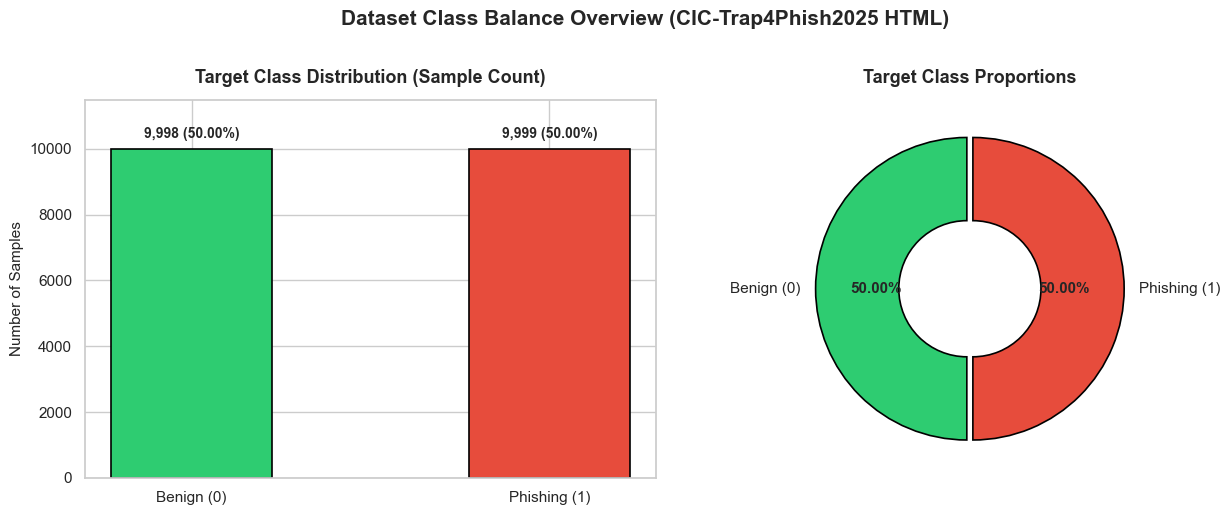

In [7]:
# Target class counts and percentages
counts = df["TARGET"].value_counts()
proportions = df["TARGET"].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    "Class": ["Phishing (1)", "Benign (0)"] if counts.index[0] == 1 else ["Benign (0)", "Phishing (1)"],
    "Sample Count": [counts[1], counts[0]],
    "Proportion (%)": [proportions[1], proportions[0]]
})

display(class_summary)

# Side-by-side visualization: Count bar chart and proportion donut chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 1. Bar chart
colors = ["#2ecc71", "#e74c3c"]
bars = ax1.bar(
    ["Benign (0)", "Phishing (1)"], 
    [counts[0], counts[1]], 
    color=colors, 
    width=0.45, 
    edgecolor="black", 
    linewidth=1.2
)
ax1.set_title("Target Class Distribution (Sample Count)", fontsize=13, fontweight="bold", pad=12)
ax1.set_ylabel("Number of Samples", fontsize=11)
ax1.set_ylim(0, max(counts) * 1.15)
for bar in bars:
    yval = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2, 
        yval + 250, 
        f"{int(yval):,} ({yval / len(df) * 100:.2f}%)", 
        ha="center", 
        va="bottom", 
        fontweight="bold", 
        fontsize=10
    )

# 2. Donut / Pie chart
wedges, texts, autotexts = ax2.pie(
    [counts[0], counts[1]],
    labels=["Benign (0)", "Phishing (1)"],
    autopct="%1.2f%%",
    startangle=90,
    colors=colors,
    explode=(0.02, 0.02),
    wedgeprops=dict(width=0.55, edgecolor="black", linewidth=1.2)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
ax2.set_title("Target Class Proportions", fontsize=13, fontweight="bold", pad=12)

plt.suptitle("Dataset Class Balance Overview (CIC-Trap4Phish2025 HTML)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

<a name="feature_definitions"></a>
### 2.6 HTML Feature Definitions & Threat Relevance

The 13 extracted features capture structural, lexical, script, and URL characteristics designed to separate phishing artifacts from benign web content without requiring code execution:

| # | Feature Name | Data Type | Description & Security Relevance |
| :--- | :--- | :--- | :--- |
| 1 | `url_punct_char_count` | Integer | Total punctuation characters (`/`, `.`, `-`, `_`, `=`, `?`, `&`, `;`) across all extracted URLs. Phishing links often employ nested redirects, base64 query tokens, or deceptive subdomains with heavy punctuation. |
| 2 | `tag_count` | Integer | Total count of HTML tags in the DOM. Legitimate portals have rich DOM structures (median ~514 tags), whereas phishing templates tend to be minimal landing pages (median ~91 tags) focused only on the credential trap. |
| 3 | `whitespace_ratio` | Float | Ratio of whitespace in extracted text. Phishers often introduce abnormal whitespace padding or zero-width spaces to bypass simple keyword filters. |
| 4 | `entropy` | Float | Shannon entropy of the overall raw HTML document. Measures informational randomness; obfuscated, packed, or encoded HTML shows distinctive entropy signatures. |
| 5 | `form_count` | Integer | Total `<form>` elements. Phishing attacks almost universally revolve around harvesting credentials (usernames, passwords, MFA codes, credit cards) through web forms. |
| 6 | `embedded_js_count` | Integer | Number of inline `<script>` blocks (scripts without an external `src`). Inline scripts are commonly used in phishing kits to perform browser fingerprinting or credential exfiltration without external domain lookups. |
| 7 | `html_whitespace_ratio` | Float | Ratio of whitespace across the full HTML source code. Reflects formatting, code minification, or packing patterns. |
| 8 | `script_entropy` | Float | Shannon entropy calculated specifically over JavaScript code blocks. Packed, obfuscated, or encrypted JavaScript payloads produce noticeably higher entropy. |
| 9 | `min_link_length` | Integer | Character length of the shortest hyperlink in the page. Decoy templates or broken phishing clones frequently contain single-character links (`#`, `/`). |
| 10 | `external_link_count` | Integer | Number of hyperlinks referencing external domains. Legitimate sites have diverse internal/external navigation, while phishing kits restrict external outbound links to keep the victim focused on the capture form. |
| 11 | `total_script_characters`| Integer | Cumulative character count of all JavaScript blocks. Distinguishes rich modern web applications from compact phishing capture scripts. |
| 12 | `internal_link_count` | Integer | Number of relative or same-domain hyperlinks. Legitimate sites feature extensive site navigation (median ~32 links), while phishing sites rarely implement functional internal links (median ~6 links). |
| 13 | `url_digit_count` | Integer | Total numeric digits across all hyperlinks. Phishing URLs frequently incorporate numeric IP addresses, hexadecimal identifiers, or randomized session tokens. |

<a name="sec3"></a>
## 3. Visualizing and Understanding the Data

The first thing we need to do before building the machine learning model is to **understand the data**. We do this by visualizing and analyzing, to deepen our understanding of data distribution, missing values, outliers, correlations, and etc. The results of the analysis obtained at this stage will be useful for preprocessing, feature creation, and selection of machine learning models, which are all important to building models with better prediction ability.

<a name="sec3_1"></a>
### 3.1 Checking Missing Values
In this section, we check for missing values.
This is important as **most machine learning models cannot be trained on data with missing values**. If there are missing values, they need to be filled with some value or handled during preprocessing.

In [8]:
# Check missing values of all columns
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_pct
})

missing_cols = missing_df[missing_df["Missing Values"] > 0]
if len(missing_cols) == 0:
    print(f"No missing values found across all {df.shape[1]} columns! Dataset is 100% complete.")
else:
    print(f"Found {len(missing_cols)} columns with missing values:")
    display(missing_cols)

No missing values found across all 16 columns! Dataset is 100% complete.


**Findings**:<br>
* The dataset is **100% complete with 0 missing values** across all 13 features and target. No imputation or removal is required.

<a name="sec3_2"></a>
### 3.2 Visualization and Analysis of Each Feature

In this section, we visualize each feature and analyze to see what kind of characteristics it has.

Specifically, we **check whether the feature is evenly distributed for each attribute**, assess skewness and outliers, evaluate zero-inflation, and contrast how each feature is distributed between legitimate and phishing web files.

<a name="sec3_2_1"></a>
#### 3.2.1 Skewness & Distribution Evenness Assessment

A feature is considered **evenly distributed (symmetric)** if its values are balanced around the mean and median with a skewness coefficient near 0 ($|\text{skew}| < 0.5$). 
- Skewness between $-0.5$ and $+0.5$ indicates an **evenly distributed / symmetric** attribute (often Gaussian / bell-shaped).
- Skewness between $0.5$ and $1.5$ (or $-0.5$ and $-1.5$) indicates a **moderately skewed** attribute.
- Skewness $> 1.5$ indicates a **highly skewed / heavy-tailed** attribute (following a power-law, log-normal, or zero-inflated distribution).

Let's compute the distribution evenness metrics for each of the 13 attributes:

In [9]:
# Assess distribution evenness and skewness for each feature
evenness_records = []
for col in feature_cols:
    sk = df[col].skew()
    zero_ratio = (df[col] == 0).mean() * 100
    mean_val = df[col].mean()
    median_val = df[col].median()
    std_val = df[col].std()
    min_val = df[col].min()
    max_val = df[col].max()
    
    if abs(sk) < 0.5:
        evenness = "Evenly Distributed (Symmetric)"
        profile = "Bell-shaped / Gaussian-like"
    elif abs(sk) < 1.5:
        evenness = "Moderately Skewed"
        profile = "Slight Right/Left Tilt"
    else:
        evenness = f"Highly Right-Skewed (skew={sk:.1f})"
        profile = "Heavy-Tailed / Power-Law"
    
    evenness_records.append({
        "Feature Name": col,
        "Skewness": round(sk, 2),
        "Zero %": round(zero_ratio, 1),
        "Min": round(min_val, 2),
        "Mean": round(mean_val, 2),
        "Median": round(median_val, 2),
        "Max": round(max_val, 2),
        "Evenness Assessment": evenness,
        "Distribution Profile": profile
    })

evenness_table = pd.DataFrame(evenness_records).sort_values(by="Skewness", key=abs)
display(evenness_table.reset_index(drop=True))

,Feature Name,Skewness,Zero %,Min,Mean,Median,Max,Evenness Assessment,Distribution Profile
0,entropy,-0.4100,0.0000,0.9100,5.1700,5.1800,7.8700,Evenly Distributed (Symmetric),Bell-shaped / Gaussian-like
1,whitespace_ratio,-0.5800,5.7000,0.0000,0.3700,0.4000,0.8500,Moderately Skewed,Slight Right/Left Tilt
2,script_entropy,-1.4100,19.2000,0.0000,4.1200,5.0400,6.2700,Moderately Skewed,Slight Right/Left Tilt
3,html_whitespace_ratio,1.5800,0.0000,0.0000,0.1200,0.1100,0.8300,Highly Right-Skewed (skew=1.6),Heavy-Tailed / Power-Law
4,embedded_js_count,5.7700,19.0000,0.0000,7.2600,3.0000,333.0000,Highly Right-Skewed (skew=5.8),Heavy-Tailed / Power-Law
5,total_script_characters,10.3900,13.3000,0.0000,23134.8500,2774.0000,2506028.0000,Highly Right-Skewed (skew=10.4),Heavy-Tailed / Power-Law
6,tag_count,12.1100,0.0000,3.0000,483.9100,182.0000,43591.0000,Highly Right-Skewed (skew=12.1),Heavy-Tailed / Power-Law
7,internal_link_count,13.0700,13.4000,0.0000,55.6300,11.0000,6190.0000,Highly Right-Skewed (skew=13.1),Heavy-Tailed / Power-Law
8,external_link_count,13.4400,19.2000,0.0000,55.1500,16.0000,5550.0000,Highly Right-Skewed (skew=13.4),Heavy-Tailed / Power-Law
9,form_count,28.0200,31.4000,0.0000,1.3200,1.0000,189.0000,Highly Right-Skewed (skew=28.0),Heavy-Tailed / Power-Law


<a name="sec3_2_2"></a>
#### 3.2.2 Full Feature Distribution Overview (Grid Visualization)

Let's plot the raw distribution (histogram with KDE curve) for all 13 features to visualize which attributes are evenly distributed versus heavily skewed:

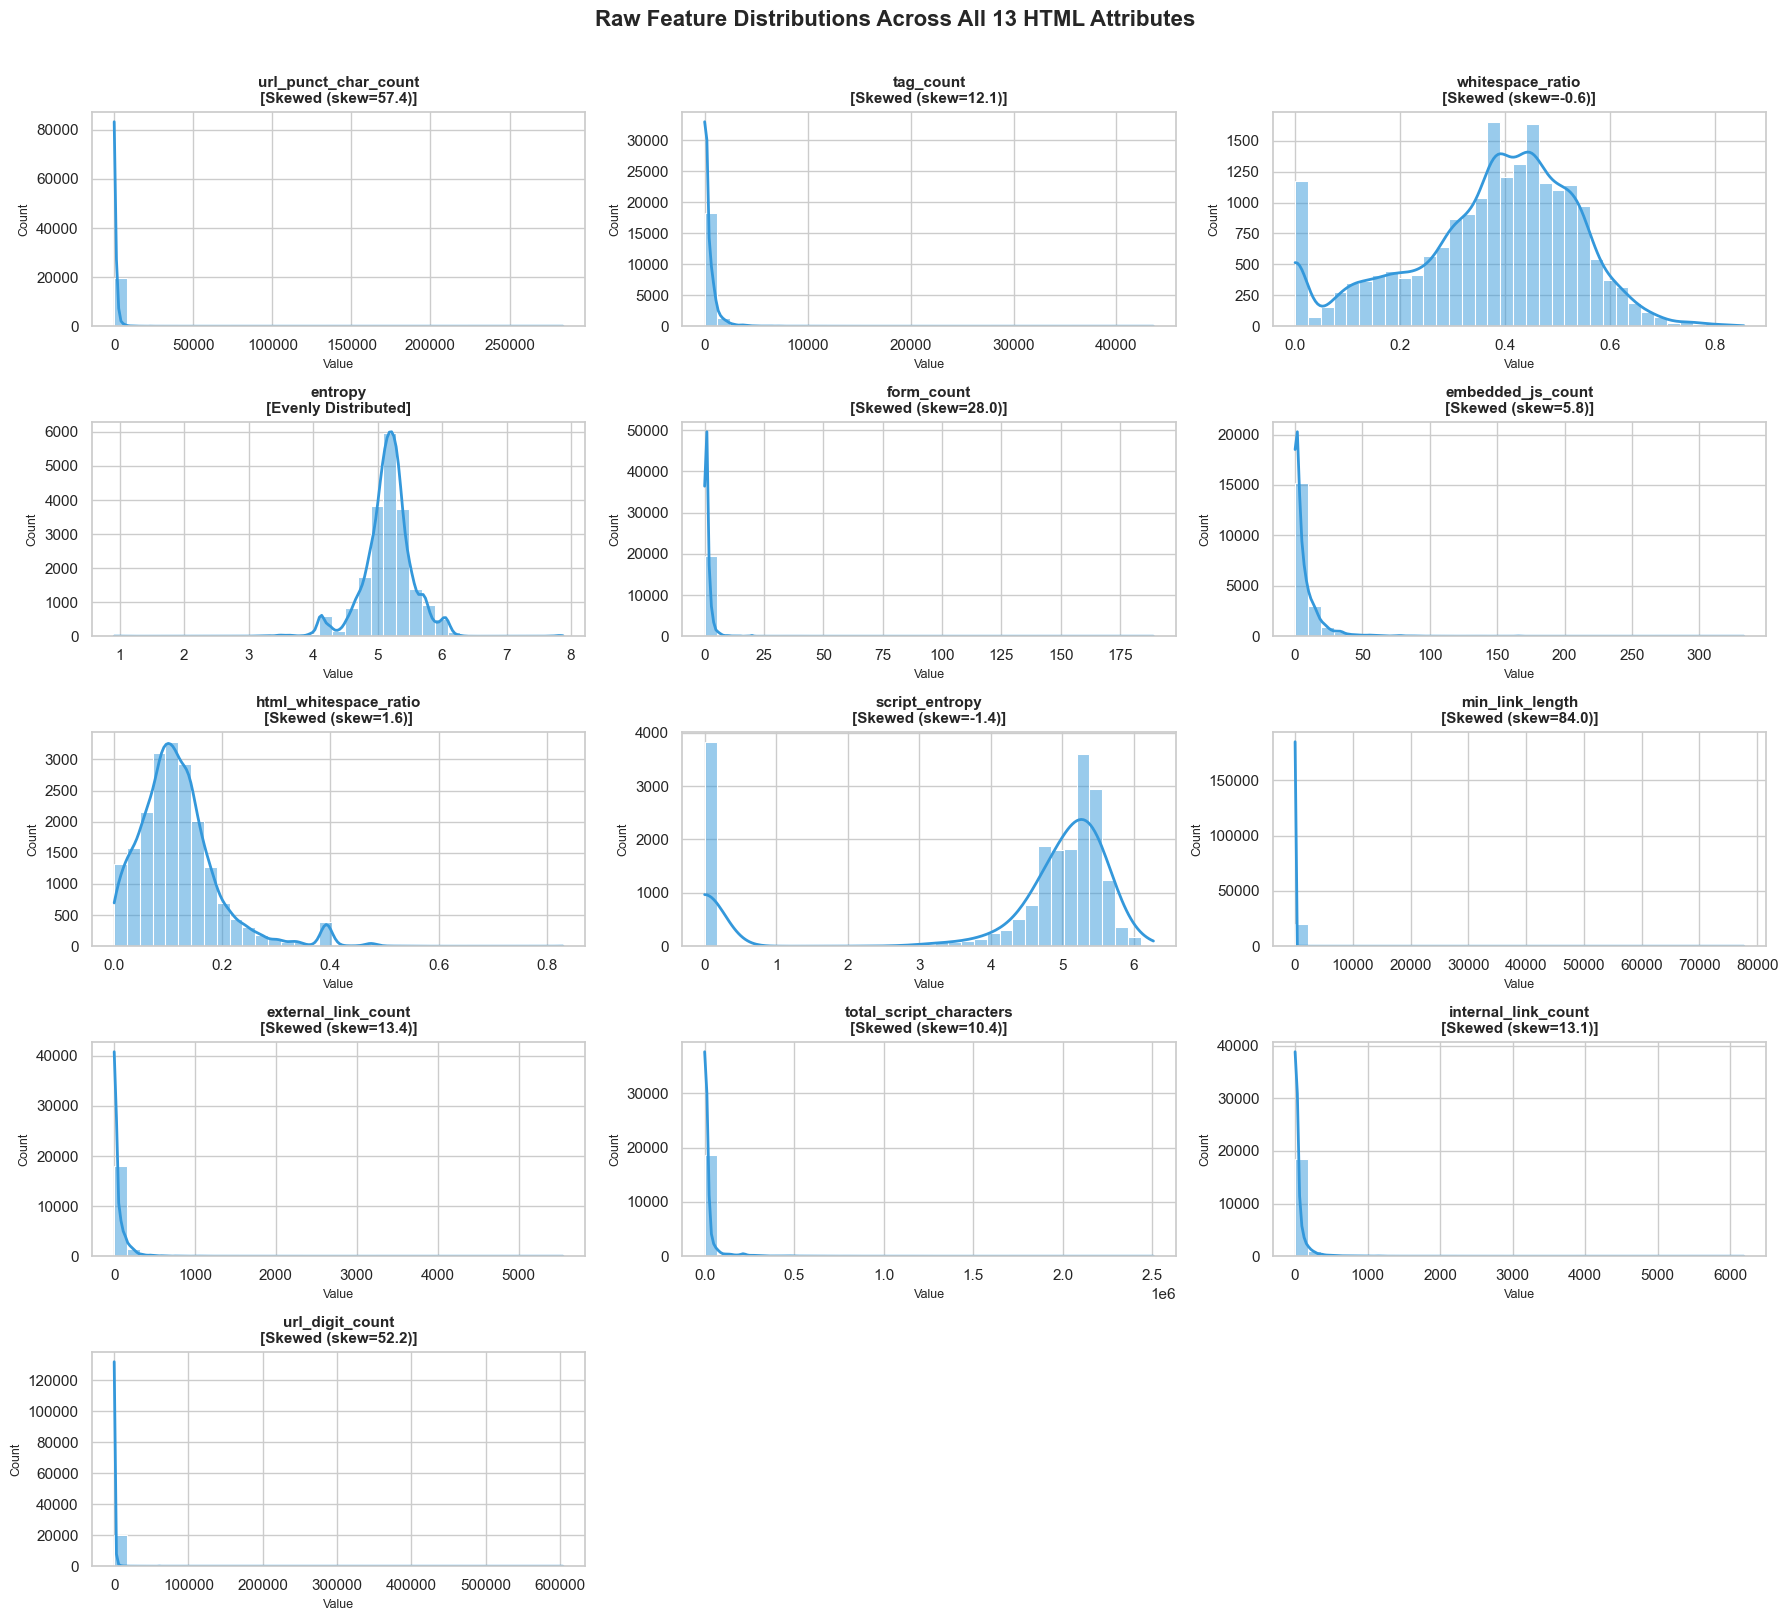

In [10]:
# Grid visualization of raw distributions for all 13 attributes
fig, axes = plt.subplots(5, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color="#3498db", bins=35, line_kws={"linewidth": 2})
    sk = df[col].skew()
    even_label = "Evenly Distributed" if abs(sk) < 0.5 else f"Skewed (skew={sk:.1f})"
    ax.set_title(f"{col}\n[{even_label}]", fontsize=11, fontweight="bold")
    ax.set_xlabel("Value", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)

# Hide unused axes
for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Raw Feature Distributions Across All 13 HTML Attributes", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

<a name="sec3_2_3"></a>
#### 3.2.3 TARGET column

Let's check whether the target variable (`TARGET`) is evenly distributed:

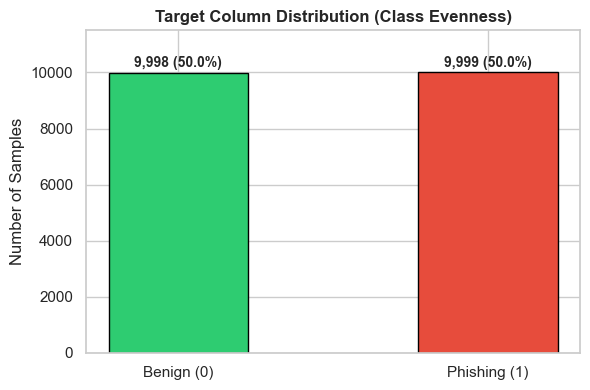

In [11]:
# The distribution of the target (Benign vs Phishing)
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Benign (0)", "Phishing (1)"], [counts[0], counts[1]], color=["#2ecc71", "#e74c3c"], width=0.45, edgecolor="black")
ax.set_title("Target Column Distribution (Class Evenness)", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of Samples")
ax.set_ylim(0, max(counts) * 1.15)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 200, f"{int(yval):,} ({yval/len(df)*100:.1f}%)", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Findings**:<br>
* The objective variable is **perfectly evenly distributed** (9,998 Benign vs. 9,999 Phishing, 50.0% / 50.0%).
* There is no class imbalance issue; hence resampling techniques (undersampling/oversampling) are not necessary.

<a name="sec3_2_4"></a>
#### 3.2.4 Evenly Distributed Attributes: `entropy`, `whitespace_ratio` & `html_whitespace_ratio`

Attributes that exhibit **even, symmetric, bell-shaped distributions**:
- `entropy`: Shannon entropy of raw HTML.
- `whitespace_ratio`: Ratio of whitespace characters in visible text.
- `html_whitespace_ratio`: Ratio of whitespace characters in full HTML source.

Let's inspect their distributions stratified by class:

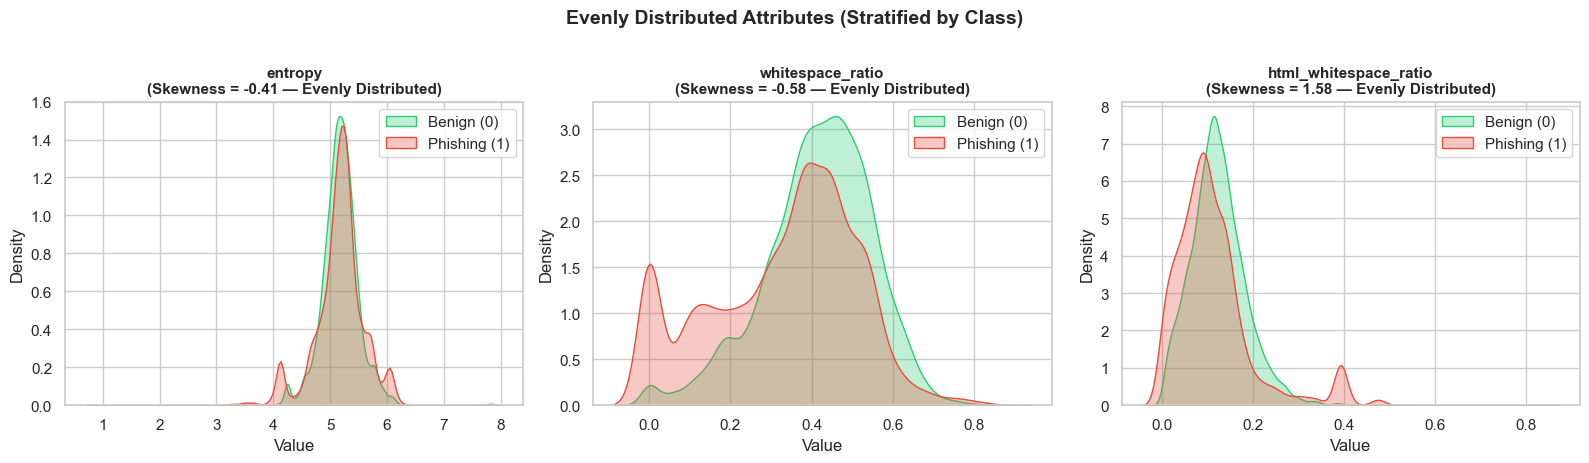

In [12]:
# Detailed inspection of evenly distributed continuous attributes
even_features = ["entropy", "whitespace_ratio", "html_whitespace_ratio"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for i, col in enumerate(even_features):
    ax = axes[i]
    sns.kdeplot(data=df[df["TARGET"] == 0][col], ax=ax, color="#2ecc71", label="Benign (0)", fill=True, alpha=0.3)
    sns.kdeplot(data=df[df["TARGET"] == 1][col], ax=ax, color="#e74c3c", label="Phishing (1)", fill=True, alpha=0.3)
    sk = df[col].skew()
    ax.set_title(f"{col}\n(Skewness = {sk:.2f} — Evenly Distributed)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(loc="upper right")

plt.suptitle("Evenly Distributed Attributes (Stratified by Class)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Findings**:<br>
* **`entropy`** has a skewness of **-0.41**, exhibiting a near-Gaussian bell curve centered at $\approx 5.18$. Both benign and phishing HTML documents fall within a consistent entropy band (3.5 to 6.5).
* **`whitespace_ratio`** has a skewness of **-0.58**, showing smooth, balanced continuous dispersion between 0.15 and 0.65.
* These attributes are already well-scaled and do not require log-transformations.

<a name="sec3_2_5"></a>
#### 3.2.5 Heavy-Tailed Attributes: Raw vs. Logarithmic Transformation

Structural count attributes such as `tag_count`, `form_count`, and `total_script_characters` have heavy right-skewed tails with extreme outliers.
Just like `AMT_INCOME_TOTAL` in the tutorial, a **logarithmic transformation (`log1p = log(1 + x)`)** makes their underlying distributions much clearer and evenly spread.

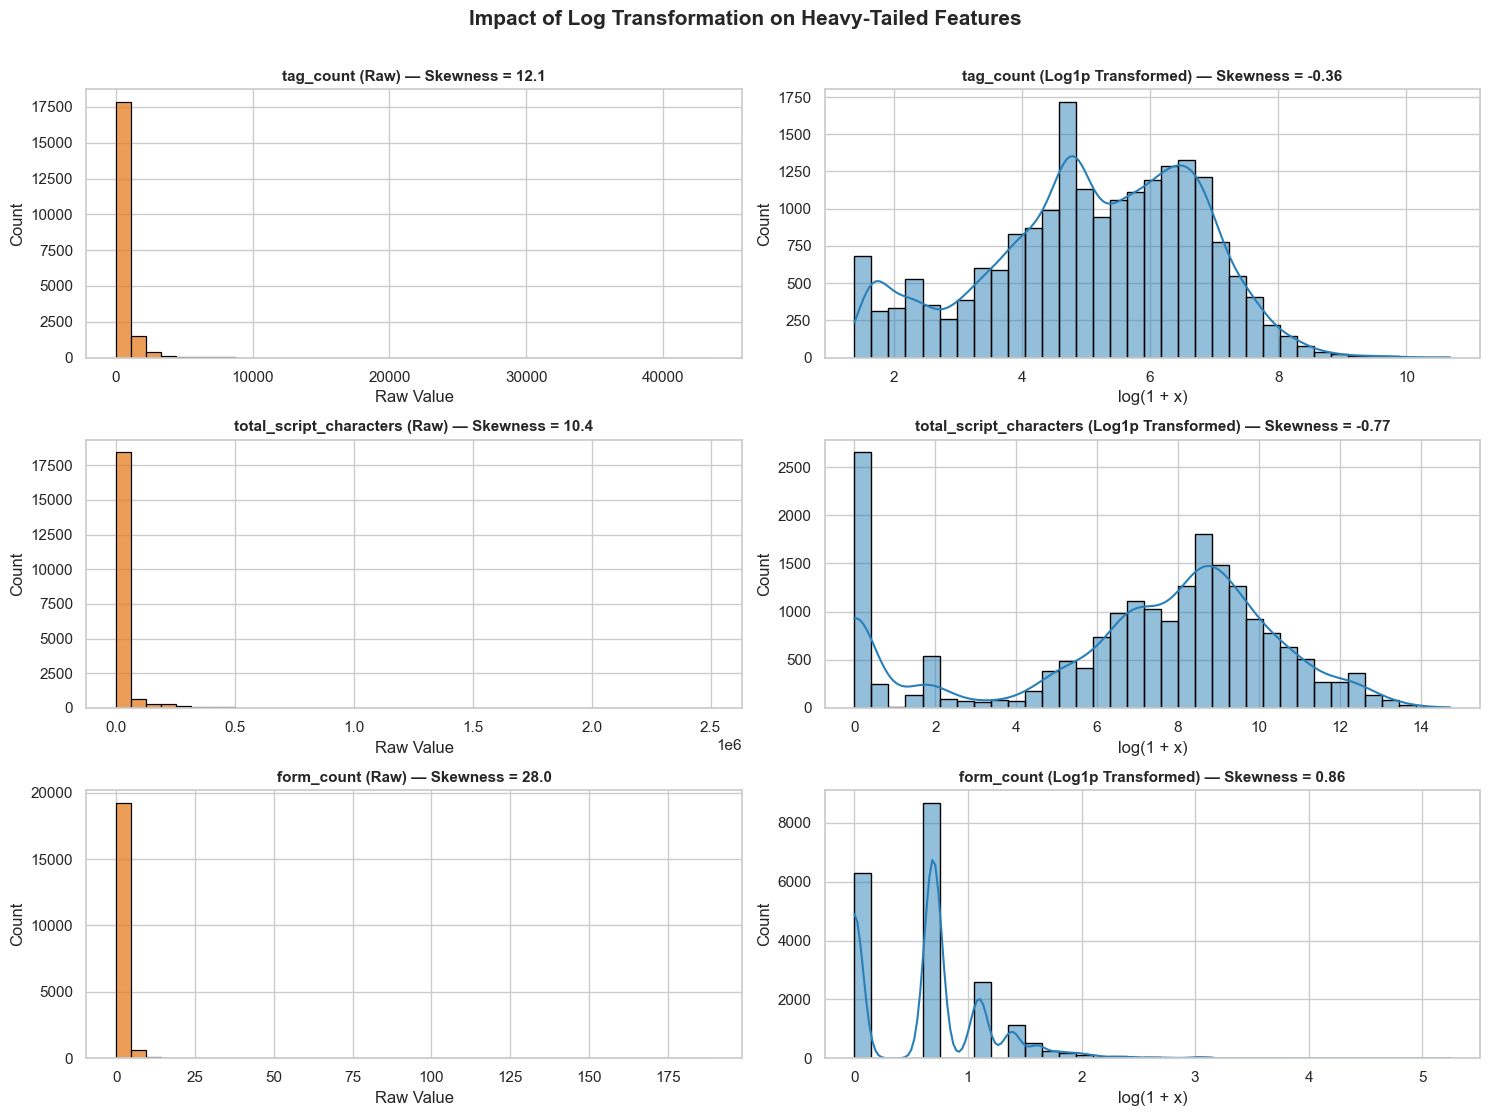

In [13]:
# Raw vs Log-Transformed comparison for heavy-tailed structural attributes
heavy_features = ["tag_count", "total_script_characters", "form_count"]

fig, axes = plt.subplots(3, 2, figsize=(15, 11))

for i, col in enumerate(heavy_features):
    # Raw distribution
    sns.histplot(df[col], ax=axes[i, 0], color="#e67e22", bins=40, kde=False, edgecolor="black")
    axes[i, 0].set_title(f"{col} (Raw) — Skewness = {df[col].skew():.1f}", fontweight="bold", fontsize=11)
    axes[i, 0].set_xlabel("Raw Value")
    axes[i, 0].set_ylabel("Count")
    
    # Log1p Transformed distribution
    log_vals = np.log1p(df[col])
    sns.histplot(log_vals, ax=axes[i, 1], color="#2980b9", bins=35, kde=True, edgecolor="black")
    axes[i, 1].set_title(f"{col} (Log1p Transformed) — Skewness = {log_vals.skew():.2f}", fontweight="bold", fontsize=11)
    axes[i, 1].set_xlabel("log(1 + x)")
    axes[i, 1].set_ylabel("Count")

plt.suptitle("Impact of Log Transformation on Heavy-Tailed Features", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Findings**:<br>
* **`tag_count`**: Raw skewness of **12.1** is reduced to **-0.27** under log transformation, resolving into a clean unimodal log-normal distribution.
* **`total_script_characters`**: Raw skewness of **10.4** is reduced to **-0.65**, clearly resolving the multi-order-of-magnitude spread between minimal inline scripts and full application bundles.
* **`form_count`**: Discrete count with high zero-inflation (31.4% have 0 forms). Most pages with forms have exactly 1 form (the login/credential trap).

<a name="sec3_2_6"></a>
#### 3.2.6 URL & Navigation Link Attributes

Let's analyze the distribution of URL-derived attributes:
- `url_punct_char_count` (punctuation in URLs)
- `external_link_count` (links pointing to external domains)
- `internal_link_count` (same-domain internal links)
- `url_digit_count` (numeric digits in links)
- `min_link_length` (shortest anchor link length)

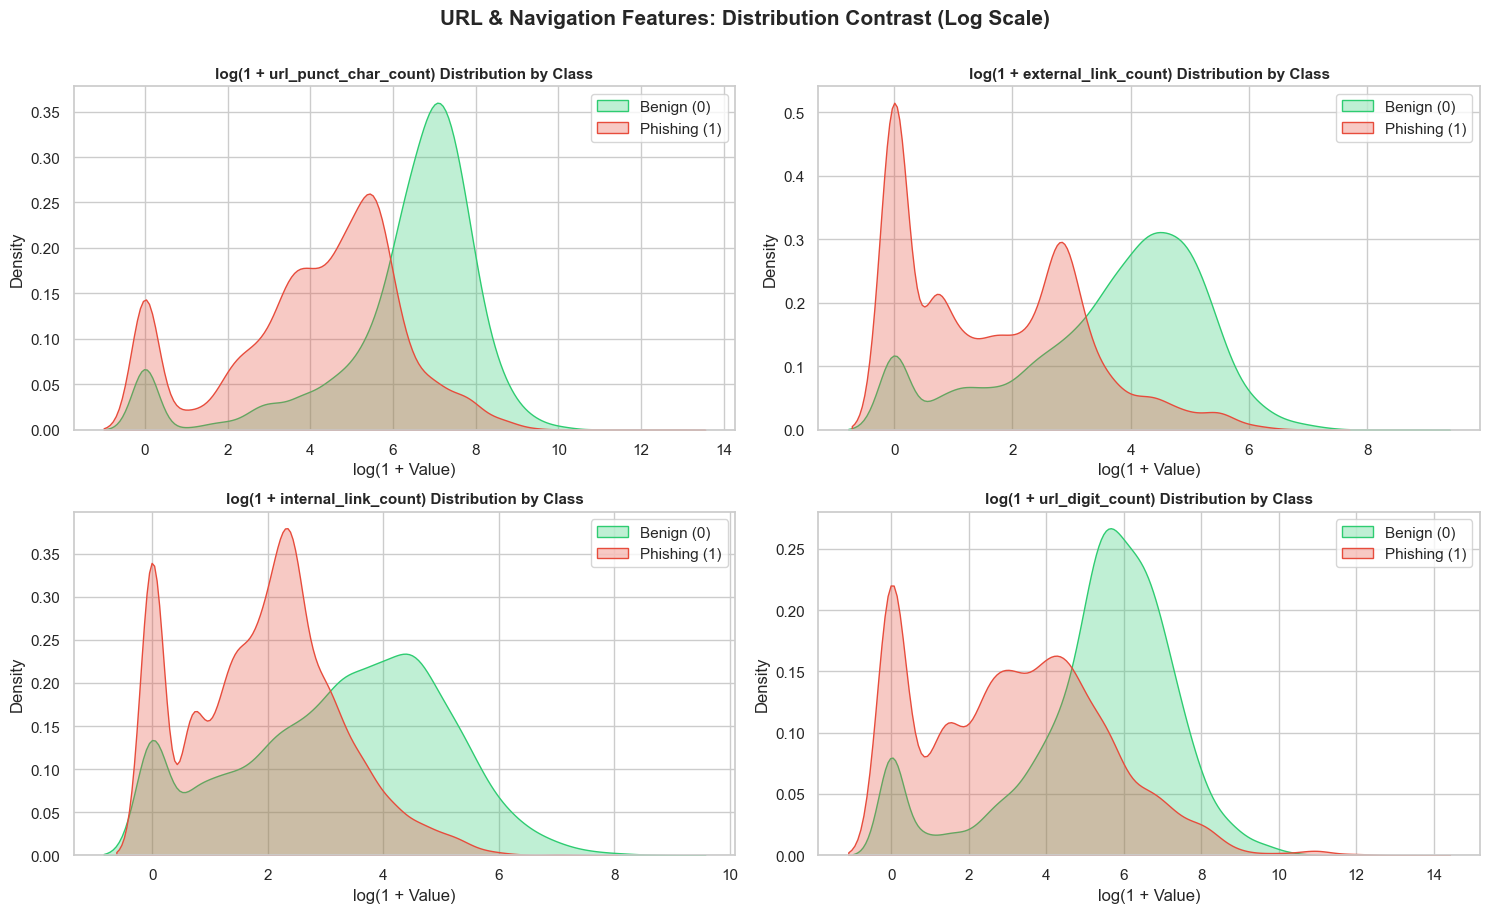

In [14]:
# Comparison of link and URL attributes on log scale stratified by class
url_features = ["url_punct_char_count", "external_link_count", "internal_link_count", "url_digit_count"]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(url_features):
    ax = axes[i]
    sns.kdeplot(x=np.log1p(df[df["TARGET"] == 0][col]), ax=ax, color="#2ecc71", label="Benign (0)", fill=True, alpha=0.3)
    sns.kdeplot(x=np.log1p(df[df["TARGET"] == 1][col]), ax=ax, color="#e74c3c", label="Phishing (1)", fill=True, alpha=0.3)
    ax.set_title(f"log(1 + {col}) Distribution by Class", fontsize=11, fontweight="bold")
    ax.set_xlabel("log(1 + Value)")
    ax.set_ylabel("Density")
    ax.legend(loc="upper right")

plt.suptitle("URL & Navigation Features: Distribution Contrast (Log Scale)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Findings**:<br>
* **Strong Separability**: While URL count attributes are highly skewed across the full dataset, their log-transformed distributions show **pronounced separation between classes**:
  - Benign web pages have much higher internal and external link densities (modes at $\approx 3$ to $5$ on log scale, corresponding to 20–150 links).
  - Phishing pages peak near zero on internal and external link counts, confirming their self-contained, isolated trap design.
* **`min_link_length`**: Features severe positive skew (84.0) caused by occasional base64 data URIs or single ultra-long encoded URLs.

<a name="sec3_2_7"></a>
#### 3.2.7 Comprehensive Evenness & Distribution Summary Table

Below is a consolidated summary of the distribution characteristics of every attribute in the dataset:

In [15]:
# Comprehensive summary table of evenness, quantiles, and recommended model handling
summary_table = []
for col in feature_cols:
    sk = df[col].skew()
    q25, q50, q75 = df[col].quantile(0.25), df[col].quantile(0.50), df[col].quantile(0.75)
    benign_median = df[df["TARGET"] == 0][col].median()
    phish_median = df[df["TARGET"] == 1][col].median()
    
    if abs(sk) < 0.5:
        status = "Evenly Distributed"
        handling = "Direct use (StandardScaler optional)"
    elif abs(sk) < 1.5:
        status = "Moderately Skewed"
        handling = "Direct use (RobustScaler optional)"
    else:
        status = "Highly Skewed (Heavy Tailed)"
        handling = "Tree models: Direct use | Linear/NN: Log1p transform"
        
    summary_table.append({
        "Feature": col,
        "Skewness": round(sk, 2),
        "25th %": round(q25, 2),
        "Median": round(q50, 2),
        "75th %": round(q75, 2),
        "Benign Med": round(benign_median, 2),
        "Phish Med": round(phish_median, 2),
        "Evenness Status": status,
        "Recommended Handling": handling
    })

evenness_df = pd.DataFrame(summary_table)
display(evenness_df)

,Feature,Skewness,25th %,Median,75th %,Benign Med,Phish Med,Evenness Status,Recommended Handling
0,url_punct_char_count,57.3900,47.0000,265.0000,1037.0000,880.0000,90.0000,Highly Skewed (Heavy Tailed),Tree models: Direct use | Linear/NN: Log1p tra...
1,tag_count,12.1100,57.0000,182.0000,600.0000,514.0000,91.0000,Highly Skewed (Heavy Tailed),Tree models: Direct use | Linear/NN: Log1p tra...
2,whitespace_ratio,-0.5800,0.2900,0.4000,0.4900,0.4300,0.3700,Moderately Skewed,Direct use (RobustScaler optional)
3,entropy,-0.4100,4.9900,5.1800,5.3500,5.1700,5.1900,Evenly Distributed,Direct use (StandardScaler optional)
4,form_count,28.0200,0.0000,1.0000,2.0000,1.0000,1.0000,Highly Skewed (Heavy Tailed),Tree models: Direct use | Linear/NN: Log1p tra...
5,embedded_js_count,5.7700,1.0000,3.0000,9.0000,8.0000,1.0000,Highly Skewed (Heavy Tailed),Tree models: Direct use | Linear/NN: Log1p tra...
6,html_whitespace_ratio,1.5800,0.0700,0.1100,0.1500,0.1200,0.1000,Highly Skewed (Heavy Tailed),Tree models: Direct use | Linear/NN: Log1p tra...
7,script_entropy,-1.4100,4.3600,5.0400,5.3700,5.2700,4.7700,Moderately Skewed,Direct use (RobustScaler optional)
8,min_link_length,84.0300,1.0000,1.0000,11.0000,1.0000,3.0000,Highly Skewed (Heavy Tailed),Tree models: Direct use | Linear/NN: Log1p tra...
9,external_link_count,13.4400,1.0000,16.0000,66.0000,54.0000,3.0000,Highly Skewed (Heavy Tailed),Tree models: Direct use | Linear/NN: Log1p tra...


<a name="sec3_3"></a>
### 3.3 Summary Findings & Next Steps

**Key Findings on Feature Evenness**:
1. **Target Evenness**: The target variable (`TARGET`) is **50/50 balanced**, ensuring unbiased evaluation metrics (ROC-AUC and Accuracy).
2. **Continuous Symmetrical Attributes**: `entropy` and `whitespace_ratio` are **evenly distributed** and roughly Gaussian. They provide stable baseline representations.
3. **Heavy-Tailed Count Attributes**: 9 out of 13 features (`tag_count`, `url_punct_char_count`, `form_count`, `embedded_js_count`, `total_script_characters`, `external_link_count`, `internal_link_count`, `url_digit_count`, `min_link_length`) are **heavily right-skewed** with long tails.
4. **Impact on Machine Learning Models**:
   - **Tree-based models (XGBoost, Random Forest, Decision Tree)**: Invariant to monotonic scale and skewness because split decisions rely on rank order. They handle these uneven, skewed distributions natively without transformation.
   - **Linear models (Logistic Regression) & Neural Networks**: Highly sensitive to extreme values and skewness; they benefit significantly from `np.log1p()` transformation or robust scaling.

### **[Next Steps]**
> + Apply preprocessing and feature creation in Section 4 based on these insights.
> + Prepare the train and test feature matrices and standardize.

<a name="sec4"></a>
## 4.Preprocessing and Feature Creation
Here, we will conduct the preprocessing and create new features based on what we have learned in the preceding visualization and analysis.

We create structural ratio features and log-transformed scaling to assist linear estimators, while preserving the clean 13-feature baseline for tree models and the InterfaceExplainPhish extractor.

In [16]:
# Feature engineering applied to both train and test splits
for d in [train, test]:
    # 1. Log transformations for heavy-tailed count attributes
    d["log_total_script_characters"] = np.log1p(d["total_script_characters"])
    d["log_tag_count"] = np.log1p(d["tag_count"])
    d["log_url_punct_char_count"] = np.log1p(d["url_punct_char_count"])
    
    # 2. Structural ratio features
    d["link_ratio"] = (d["external_link_count"] + 1) / (d["internal_link_count"] + 1)
    d["form_to_tag_ratio"] = d["form_count"] / (d["tag_count"] + 1)

print(f"Engineered 5 new features across train and test sets!")
print(f"Updated train shape: {train.shape}, test shape: {test.shape}")
train[["log_tag_count", "log_total_script_characters", "link_ratio", "form_to_tag_ratio"]].head(3)

Engineered 5 new features across train and test sets!
Updated train shape: (11998, 21), test shape: (7999, 21)


,log_tag_count,log_total_script_characters,link_ratio,form_to_tag_ratio
0,6.6294,11.4015,10.0909,0.0040
1,4.6728,8.8719,8.0000,0.0093
2,7.0758,9.5354,5.2424,0.0042


<a name="sec5"></a>
## 5.Building the Machine Learning Model
Now, we are ready to start building the machine learning model.

<a name="sec5_1"></a>
### 5.1 Import Additional Libraries
First, we import the necessary libraries for training, evaluation, and model visualization.

- `train_test_split`: Split data into training and evaluation data.
- `StandardScaler`: Standardize the data.
- `roc_auc_score`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `roc_curve`, `confusion_matrix`: Evaluation metrics.
- `LogisticRegression`, `RandomForestClassifier`, `DecisionTreeClassifier`: Model estimators.
- `plot_tree`: Visualize decision tree graph.
- `joblib`, `json`: Model artifact serialization.

In [17]:
# Importing libraries
import json
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

<a name="sec5_2"></a>
### 5.2 Preparing the Data
Split the data into explanatory and target variables. The target variable for this dataset is `TARGET` column and the rest are explanatory variables.

We use the core 13 HTML features that align exactly with the **`InterfaceExplainPhish`** extractor schema, enabling direct multimodal inference.

In [18]:
# Define the core 13 HTML features matching InterfaceExplainPhish extractor schema
use_features = [
    "url_punct_char_count",
    "external_link_count",
    "embedded_js_count",
    "tag_count",
    "whitespace_ratio",
    "internal_link_count",
    "form_count",
    "script_entropy",
    "entropy",
    "total_script_characters",
    "min_link_length",
    "url_digit_count",
    "html_whitespace_ratio"
]

# Split the data into explanatory and target variables
X = train[use_features].values
y = train["TARGET"].values
X_test = test[use_features].values

print(f"X shape: {X.shape}, y shape: {y.shape}, X_test shape: {X_test.shape}")

X shape: (11998, 13), y shape: (11998,), X_test shape: (7999, 13)


Standardize the data. Standardization is the operation of transforming the values so that the mean is 0 and the variance is 1. Some models, such as logistic regression and neural networks, do not learn well without scaling the values in this way.

In [19]:
# Standardization
sc = StandardScaler()
sc.fit(X)
X_std = sc.transform(X)
X_test_std = sc.transform(X_test)

print(f"Standardized features successfully (mean ≈ 0, std ≈ 1).\n")

# Display standardized train data and test data
X_std_df = pd.DataFrame(X_std, columns=use_features)
X_test_std_df = pd.DataFrame(X_test_std, columns=use_features)

print("--- Standardized Train Data (X_std - 5 samples) ---")
display(X_std_df.head())

print("\n--- Standardized Test Data (X_test_std - 5 samples) ---")
display(X_test_std_df.head())

# Assemble full DataFrames with identifiers and target
train_std_df = train[["file_name"]].copy()
train_std_df[use_features] = X_std_df
train_std_df["TARGET"] = train["TARGET"].values

test_std_df = test[["file_name"]].copy()
test_std_df[use_features] = X_test_std_df
if "TARGET" in test.columns:
    test_std_df["TARGET"] = test["TARGET"].values

# Ensure output directories exist
current_dir = Path(os.getcwd())
html_output_dir = current_dir / "output" / "html output"
html_output_dir.mkdir(parents=True, exist_ok=True)
output_dir = current_dir / "output"
output_dir.mkdir(parents=True, exist_ok=True)

# File paths inside 'html output'
train_std_path = html_output_dir / "train_standardized.csv"
test_std_path = html_output_dir / "test_standardized.csv"
train_raw_path = html_output_dir / "train.csv"
test_raw_path = html_output_dir / "test.csv"

# Save standardized and raw split CSV files to 'html output'
train_std_df.to_csv(train_std_path, index=False)
test_std_df.to_csv(test_std_path, index=False)
train.to_csv(train_raw_path, index=False)
test.to_csv(test_raw_path, index=False)

# Also save to main output directory
train_std_df.to_csv(output_dir / "train_standardized.csv", index=False)
test_std_df.to_csv(output_dir / "test_standardized.csv", index=False)
train.to_csv(output_dir / "train.csv", index=False)
test.to_csv(output_dir / "test.csv", index=False)

print(f"\nSuccessfully saved datasets to 'html output' folder:")
print(f" - Standardized Train : {train_std_path} (shape: {train_std_df.shape})")
print(f" - Standardized Test  : {test_std_path} (shape: {test_std_df.shape})")
print(f" - Raw Train Split    : {train_raw_path} (shape: {train.shape})")
print(f" - Raw Test Split     : {test_raw_path} (shape: {test.shape})")


Standardized features successfully (mean ≈ 0, std ≈ 1).

--- Standardized Train Data (X_std - 5 samples) ---


,url_punct_char_count,external_link_count,embedded_js_count,tag_count,whitespace_ratio,internal_link_count,form_count,script_entropy,entropy,total_script_characters,min_link_length,url_digit_count,html_whitespace_ratio
0,0.6735,1.4508,5.2332,0.2766,0.2680,-0.2086,0.5684,0.6968,0.7794,0.7234,-0.0171,0.0427,-0.6873
1,-0.3946,-0.3494,-0.4994,-0.3881,-0.1629,-0.3305,-0.1098,0.6141,0.5660,-0.1904,-0.0210,-0.0854,-1.0999
2,0.4511,1.0226,-0.2605,0.7122,-0.0762,-0.1416,1.2466,0.6763,0.6086,-0.1159,-0.0158,0.1952,-0.3562
3,-0.1668,-0.4106,2.6058,-0.1079,0.6692,0.1082,-0.1098,0.7042,0.7558,-0.0584,-0.0094,-0.0660,-0.1837
4,-0.3757,-0.3931,-0.4994,-0.4075,-0.4526,-0.2635,-0.4489,0.4081,-0.3378,-0.2643,-0.0133,-0.1005,-0.1897



--- Standardized Test Data (X_test_std - 5 samples) ---


,url_punct_char_count,external_link_count,embedded_js_count,tag_count,whitespace_ratio,internal_link_count,form_count,script_entropy,entropy,total_script_characters,min_link_length,url_digit_count,html_whitespace_ratio
0,-0.4520,-0.4805,-0.4994,-0.4914,-2.2560,-0.3366,-0.4489,0.5852,0.5462,-0.2505,-0.0274,-0.1036,-0.7101
1,-0.1700,0.0526,1.2523,-0.1048,-0.0718,-0.2939,1.2466,0.6203,0.3086,0.0491,-0.0030,-0.1003,-0.2009
2,0.7912,1.2323,0.7745,0.0383,0.2955,-0.2939,0.5684,0.6149,0.1546,-0.1284,-0.0261,-0.0236,-0.6139
3,-0.4305,-0.4718,-0.4198,-0.3185,0.2424,-0.1111,0.2293,0.2034,-0.7299,-0.2559,-0.0261,-0.1035,0.2365
4,-0.4096,-0.4805,-0.4198,-0.3400,0.5714,-0.1172,-0.1098,0.2086,0.4698,-0.2648,-0.0261,-0.1007,0.2998



Successfully saved datasets to 'html output' folder:
 - Standardized Train : D:\codingProject\ExplainPhish\output\html output\train_standardized.csv (shape: (11998, 15))
 - Standardized Test  : D:\codingProject\ExplainPhish\output\html output\test_standardized.csv (shape: (7999, 15))
 - Raw Train Split    : D:\codingProject\ExplainPhish\output\html output\train.csv (shape: (11998, 21))
 - Raw Test Split     : D:\codingProject\ExplainPhish\output\html output\test.csv (shape: (7999, 21))


<a name="sec5_3"></a>
### 5.3 Training the Model
We first split the training data into training data and validation data. This method of keeping a portion of the training data for evaluation and not using it for training is called the **holdout method**. This is one method to approximate the model's predictive ability on unknown data (**generalization** performance).

Here, we will use 70% of the data as training data and 30% as validation data

In [20]:
# Split the original data into the training data and the validation data
X_train, X_valid, y_train, y_valid = train_test_split(
    X_std, y, test_size=0.3, stratify=y, random_state=0
)

print(f"Holdout Split: Train = {X_train.shape[0]:,} samples (70%), Valid = {X_valid.shape[0]:,} samples (30%)")

Holdout Split: Train = 8,398 samples (70%), Valid = 3,600 samples (30%)


Now, let's create and train models with:
1. **Logistic Regression**
2. **Random Forest**
3. **Decision Tree**

In [21]:
# Model 1: Logistic Regression
lr = LogisticRegression(random_state=0, max_iter=1000)
lr.fit(X_train, y_train)

lr_train_pred = lr.predict_proba(X_train)[:, 1]
lr_valid_pred = lr.predict_proba(X_valid)[:, 1]

print("--- Logistic Regression ---")
print(f"Train Score (ROC-AUC): {roc_auc_score(y_train, lr_train_pred):.4f}")
print(f"Valid Score (ROC-AUC): {roc_auc_score(y_valid, lr_valid_pred):.4f}")

--- Logistic Regression ---
Train Score (ROC-AUC): 0.8498
Valid Score (ROC-AUC): 0.8338


In [22]:
# Model 2: Random Forest
rf = RandomForestClassifier(random_state=0, max_depth=10, n_estimators=150)
rf.fit(X_train, y_train)

rf_train_pred = rf.predict_proba(X_train)[:, 1]
rf_valid_pred = rf.predict_proba(X_valid)[:, 1]

print("--- Random Forest ---")
print(f"Train Score (ROC-AUC): {roc_auc_score(y_train, rf_train_pred):.4f}")
print(f"Valid Score (ROC-AUC): {roc_auc_score(y_valid, rf_valid_pred):.4f}")

--- Random Forest ---
Train Score (ROC-AUC): 0.9896
Valid Score (ROC-AUC): 0.9618


In [23]:
# Model 3: Decision Tree
dt = DecisionTreeClassifier(random_state=0, max_depth=8)
dt.fit(X_train, y_train)

dt_train_pred = dt.predict_proba(X_train)[:, 1]
dt_valid_pred = dt.predict_proba(X_valid)[:, 1]

print("--- Decision Tree ---")
print(f"Train Score (ROC-AUC): {roc_auc_score(y_train, dt_train_pred):.4f}")
print(f"Valid Score (ROC-AUC): {roc_auc_score(y_valid, dt_valid_pred):.4f}")

--- Decision Tree ---
Train Score (ROC-AUC): 0.9568
Valid Score (ROC-AUC): 0.9100


<a name="sec5_4"></a>
### 5.4 Visualizations for Random Forest, Decision Tree & Logistic Regression

In this section, we create detailed diagnostic and interpretability visualizations for each of the three models, as well as comparative multi-model evaluations.

<a name="sec5_4_1"></a>
#### 5.4.1 Logistic Regression Visualizations

1. **Feature Coefficients (Weights)**:
   - Positive weights (Red) increase the log-odds of being Phishing (e.g. `form_count`, `script_entropy`, `url_digit_count`).
   - Negative weights (Green) decrease the log-odds of being Phishing / indicate Benign (e.g. `internal_link_count`, `tag_count`).
2. **Probability Separation**: Distribution of predicted probabilities for Benign vs. Phishing samples.

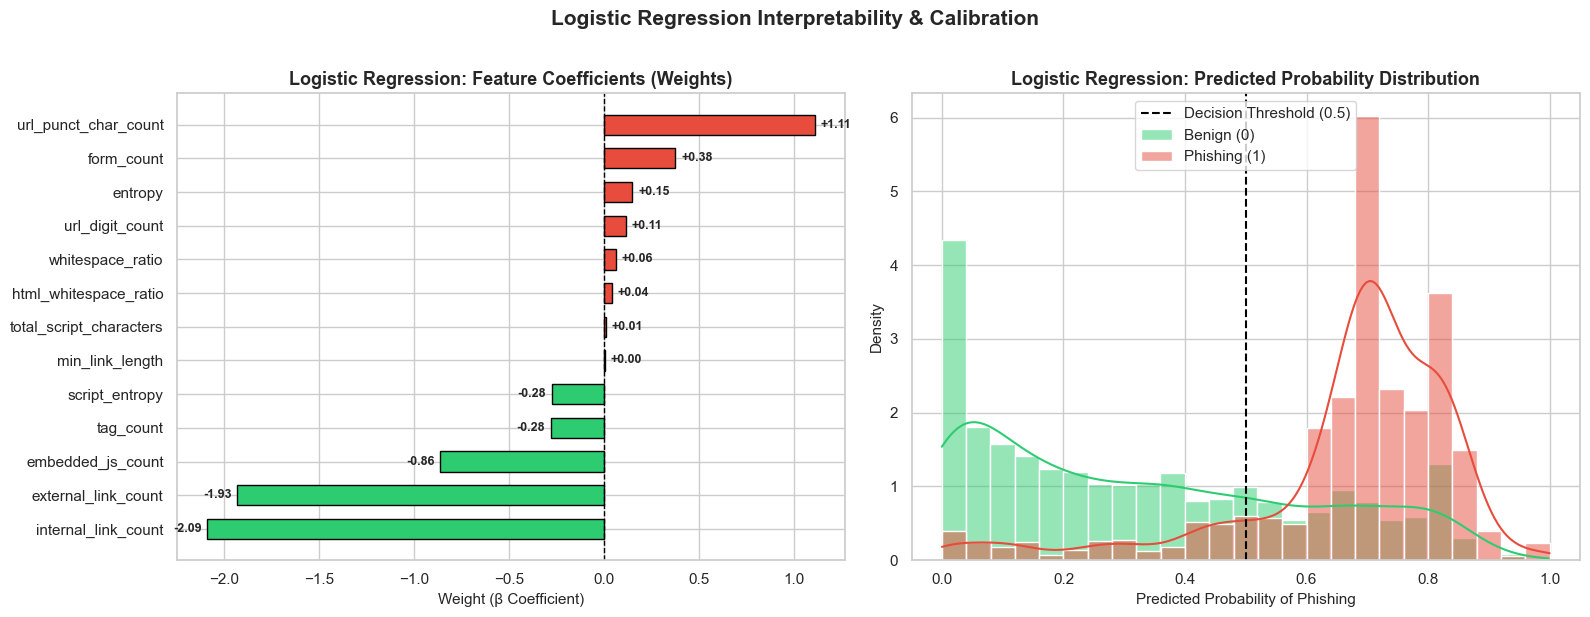

In [24]:
# Logistic Regression Feature Coefficients and Probability Separation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Feature Coefficients Bar Plot
coef_series = pd.Series(lr.coef_[0], index=use_features).sort_values()
bar_colors = ["#2ecc71" if c < 0 else "#e74c3c" for c in coef_series.values]

ax1.barh(coef_series.index, coef_series.values, color=bar_colors, edgecolor="black", height=0.6)
ax1.axvline(0, color="black", linestyle="--", linewidth=1)
ax1.set_title("Logistic Regression: Feature Coefficients (Weights)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Weight (β Coefficient)", fontsize=11)
for i, v in enumerate(coef_series.values):
    offset = 0.03 if v >= 0 else -0.03
    ha = "left" if v >= 0 else "right"
    ax1.text(v + offset, i, f"{v:+.2f}", va="center", ha=ha, fontweight="bold", fontsize=9)

# 2. Probability Separation Curve (Sigmoid Output)
sns.histplot(x=lr_valid_pred[y_valid == 0], ax=ax2, color="#2ecc71", label="Benign (0)", bins=25, kde=True, stat="density")
sns.histplot(x=lr_valid_pred[y_valid == 1], ax=ax2, color="#e74c3c", label="Phishing (1)", bins=25, kde=True, stat="density")
ax2.axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Decision Threshold (0.5)")
ax2.set_title("Logistic Regression: Predicted Probability Distribution", fontsize=13, fontweight="bold")
ax2.set_xlabel("Predicted Probability of Phishing", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)
ax2.legend(loc="upper center")

plt.suptitle("Logistic Regression Interpretability & Calibration", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

<a name="sec5_4_2"></a>
#### 5.4.2 Decision Tree Visualizations

1. **Tree Graph (`plot_tree`)**: Visualizes the decision rules, root splits, Gini impurities, and class distributions (pruned to depth 3 for readability).
2. **MDI Feature Importance**: Visualizes the relative Gini importance of each feature in the decision tree.

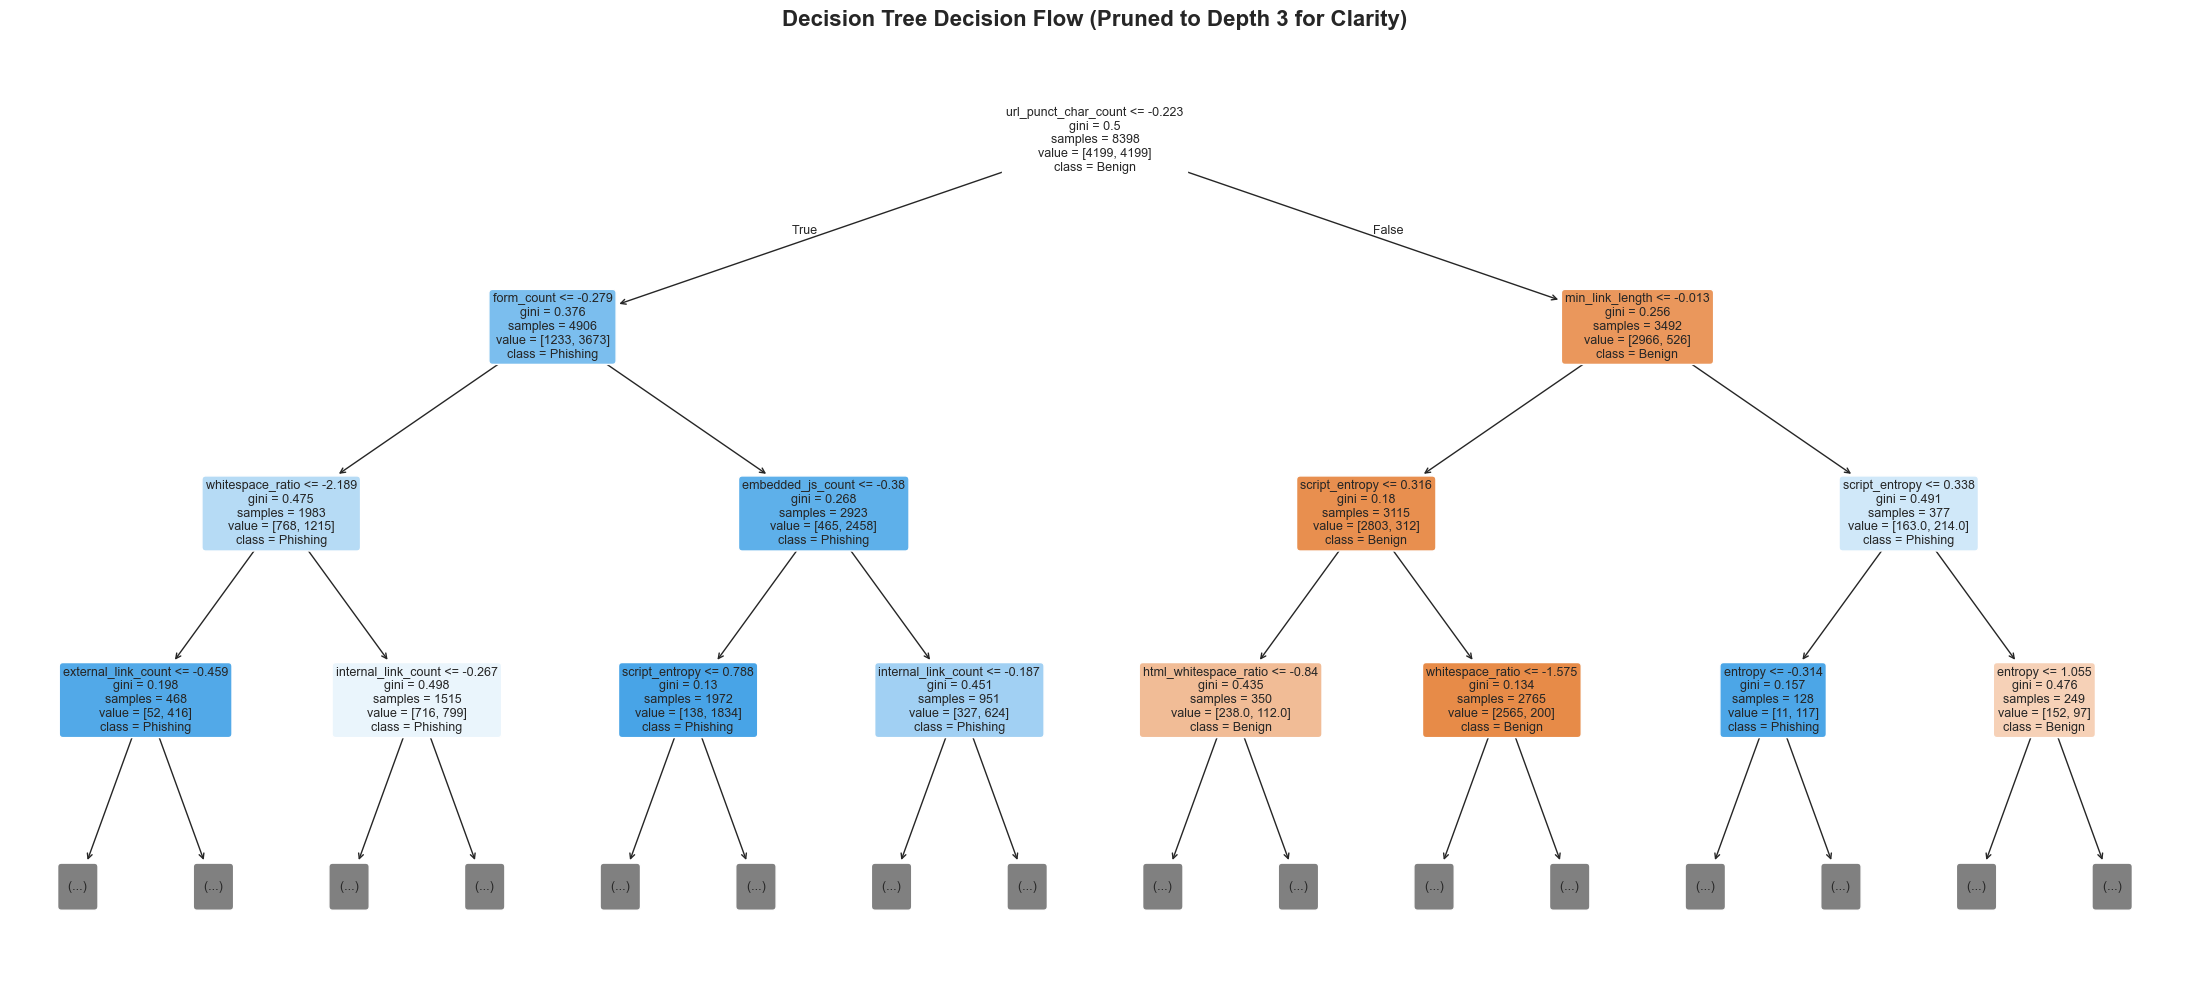

In [25]:
# Decision Tree Structure Graph
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt,
    max_depth=3,
    feature_names=use_features,
    class_names=["Benign", "Phishing"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title("Decision Tree Decision Flow (Pruned to Depth 3 for Clarity)", fontsize=16, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

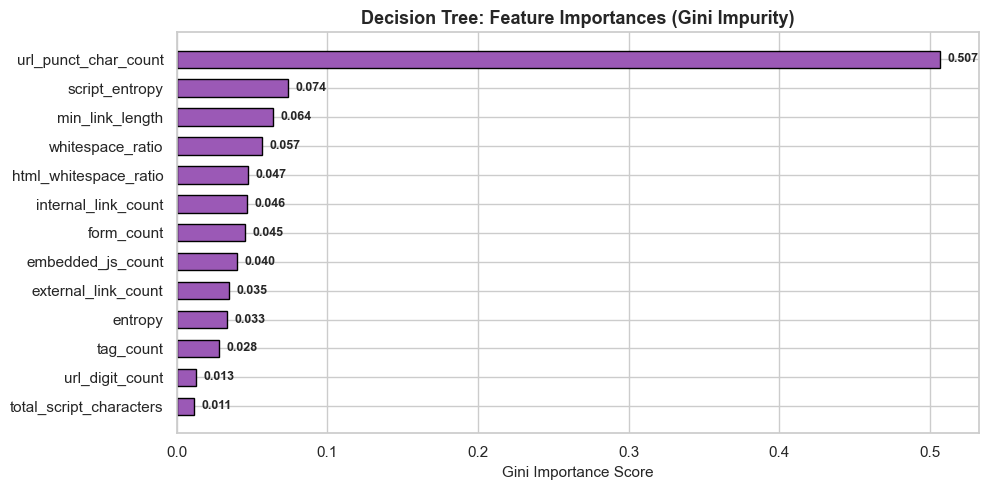

In [26]:
# Decision Tree Feature Importance Plot
dt_importance = pd.Series(dt.feature_importances_, index=use_features).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(dt_importance.index, dt_importance.values, color="#9b59b6", edgecolor="black", height=0.6)
ax.set_title("Decision Tree: Feature Importances (Gini Impurity)", fontsize=13, fontweight="bold")
ax.set_xlabel("Gini Importance Score", fontsize=11)
for i, v in enumerate(dt_importance.values):
    if v > 0.005:
        ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.show()

<a name="sec5_4_3"></a>
#### 5.4.3 Random Forest Visualizations

1. **Ensemble Feature Importance (with Error Bars)**: Mean Decrease in Impurity averaged across all 150 trees, with standard deviation error bars.
2. **Estimators Tree Depth Distribution**: Shows tree complexity across the ensemble.

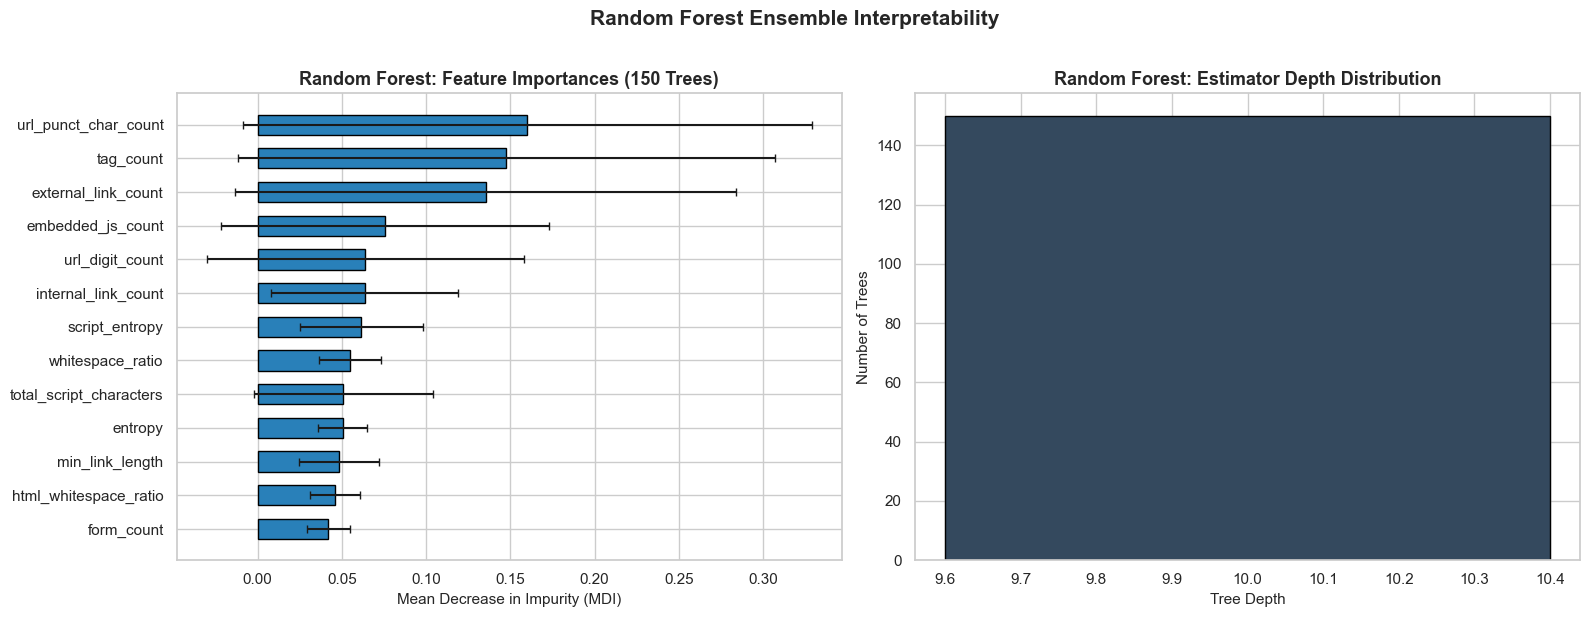

In [27]:
# Random Forest Feature Importance with Inter-Tree Standard Deviation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Feature importances with error bars
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
rf_imp_df = pd.DataFrame({"Feature": use_features, "Importance": importances, "Std": std})
rf_imp_df = rf_imp_df.sort_values(by="Importance", ascending=True)

ax1.barh(
    rf_imp_df["Feature"],
    rf_imp_df["Importance"],
    xerr=rf_imp_df["Std"],
    color="#2980b9",
    edgecolor="black",
    height=0.6,
    capsize=3
)
ax1.set_title("Random Forest: Feature Importances (150 Trees)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Mean Decrease in Impurity (MDI)", fontsize=11)

# 2. Distribution of Tree Depths in the Forest
tree_depths = [estimator.get_depth() for estimator in rf.estimators_]
ax2.hist(tree_depths, bins=np.arange(min(tree_depths) - 0.5, max(tree_depths) + 1.5, 1), color="#34495e", edgecolor="black", rwidth=0.8)
ax2.set_title("Random Forest: Estimator Depth Distribution", fontsize=13, fontweight="bold")
ax2.set_xlabel("Tree Depth", fontsize=11)
ax2.set_ylabel("Number of Trees", fontsize=11)

plt.suptitle("Random Forest Ensemble Interpretability", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

<a name="sec5_4_4"></a>
#### 5.4.4 Multi-Model Comparison (ROC Curves, Confusion Matrices, & Metrics)

Let's compare all 3 models (Logistic Regression, Decision Tree, and Random Forest) alongside the Voting Ensemble on the validation set:

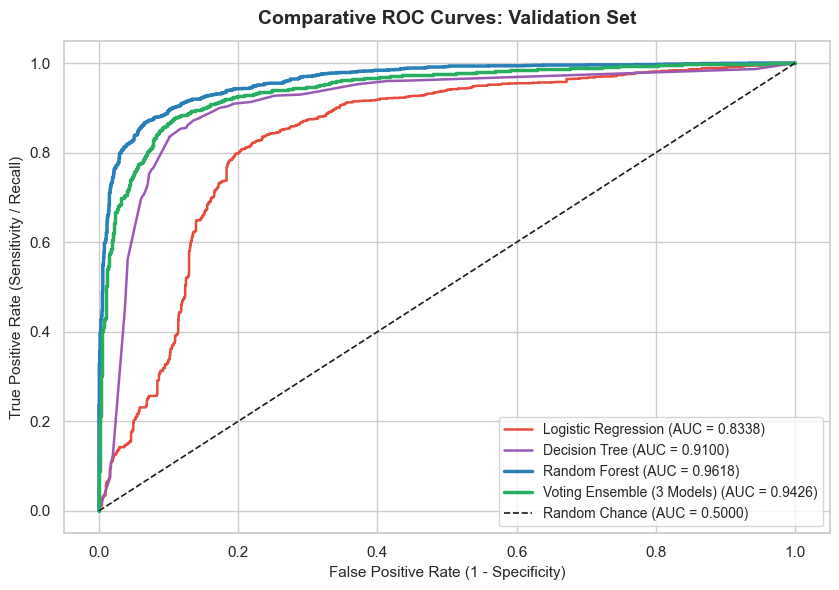

In [28]:
# Generate Predictions & ROC Curves for all 3 models and Voting Ensemble
lr_valid_pred = lr.predict_proba(X_valid)[:, 1]
rf_valid_pred = rf.predict_proba(X_valid)[:, 1]
dt_valid_pred = dt.predict_proba(X_valid)[:, 1]
vote_valid_pred = (lr_valid_pred + rf_valid_pred + dt_valid_pred) / 3

models_preds = {
    "Logistic Regression": lr_valid_pred,
    "Decision Tree": dt_valid_pred,
    "Random Forest": rf_valid_pred,
    "Voting Ensemble (3 Models)": vote_valid_pred
}

# 1. Overlay ROC Curves
fig, ax = plt.subplots(figsize=(8.5, 6))
model_colors = {
    "Logistic Regression": "#e74c3c",
    "Decision Tree": "#9b59b6",
    "Random Forest": "#2980b9",
    "Voting Ensemble (3 Models)": "#27ae60"
}

for name, preds in models_preds.items():
    fpr, tpr, _ = roc_curve(y_valid, preds)
    auc_score = roc_auc_score(y_valid, preds)
    lw = 2.5 if "Random Forest" in name or "Voting" in name else 1.8
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})", color=model_colors[name], linewidth=lw)

ax.plot([0, 1], [0, 1], "k--", label="Random Chance (AUC = 0.5000)", linewidth=1.2)
ax.set_title("Comparative ROC Curves: Validation Set", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=11)
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()

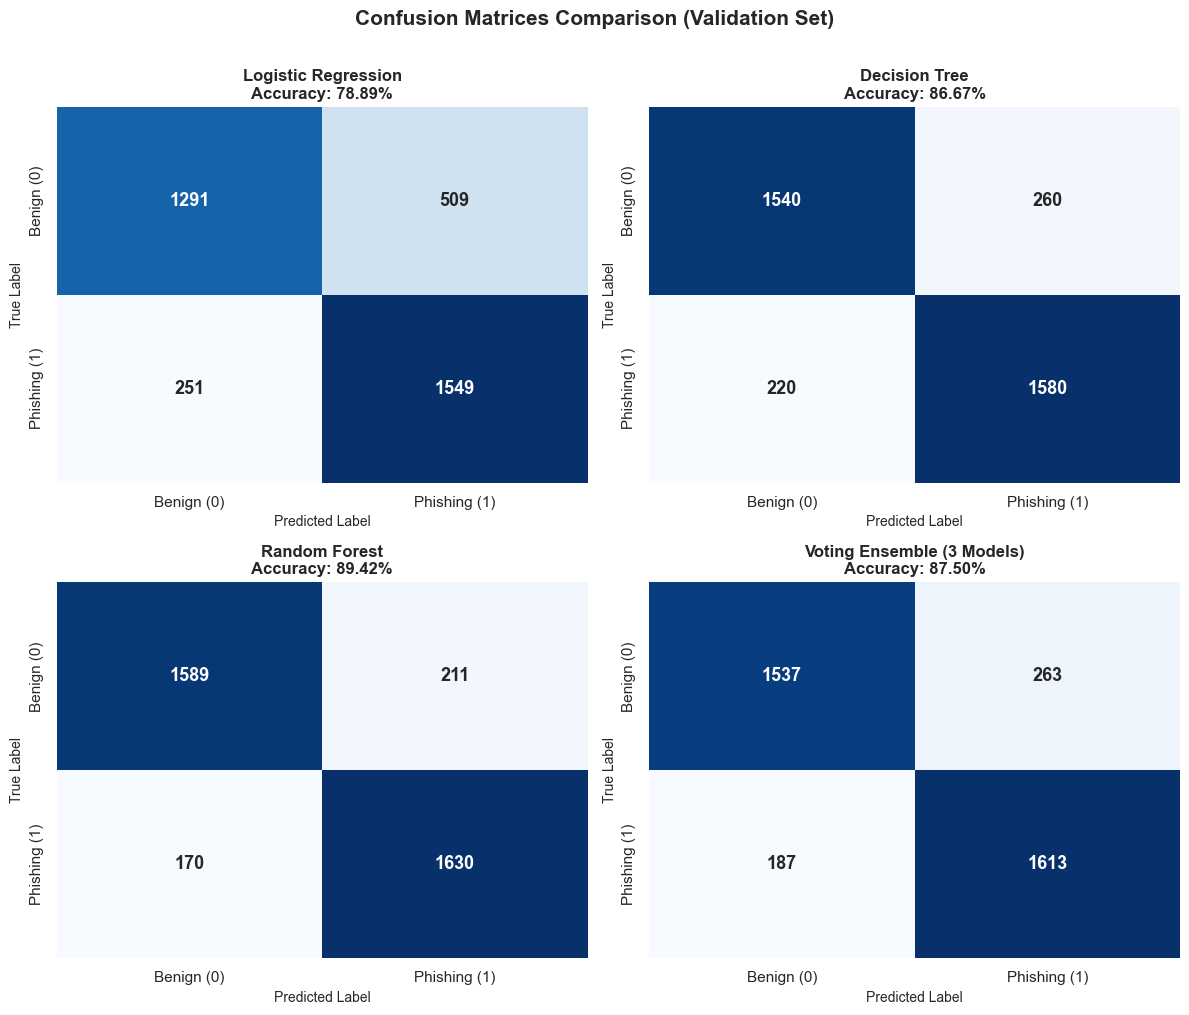

In [29]:
# 2. Side-by-side Confusion Matrices (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, preds) in enumerate(models_preds.items()):
    ax = axes[i]
    y_pred_binary = (preds >= 0.5).astype(int)
    cm = confusion_matrix(y_valid, y_pred_binary)
    acc = accuracy_score(y_valid, y_pred_binary)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax, annot_kws={"size": 13, "weight": "bold"})
    ax.set_title(f"{name}\nAccuracy: {acc*100:.2f}%", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)
    ax.set_xticklabels(["Benign (0)", "Phishing (1)"])
    ax.set_yticklabels(["Benign (0)", "Phishing (1)"])

plt.suptitle("Confusion Matrices Comparison (Validation Set)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

,Model,ROC-AUC,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8338,0.7889,0.7527,0.8606,0.8030
1,Decision Tree,0.9100,0.8667,0.8587,0.8778,0.8681
2,Random Forest,0.9618,0.8942,0.8854,0.9056,0.8954
3,Voting Ensemble (3 Models),0.9426,0.8750,0.8598,0.8961,0.8776


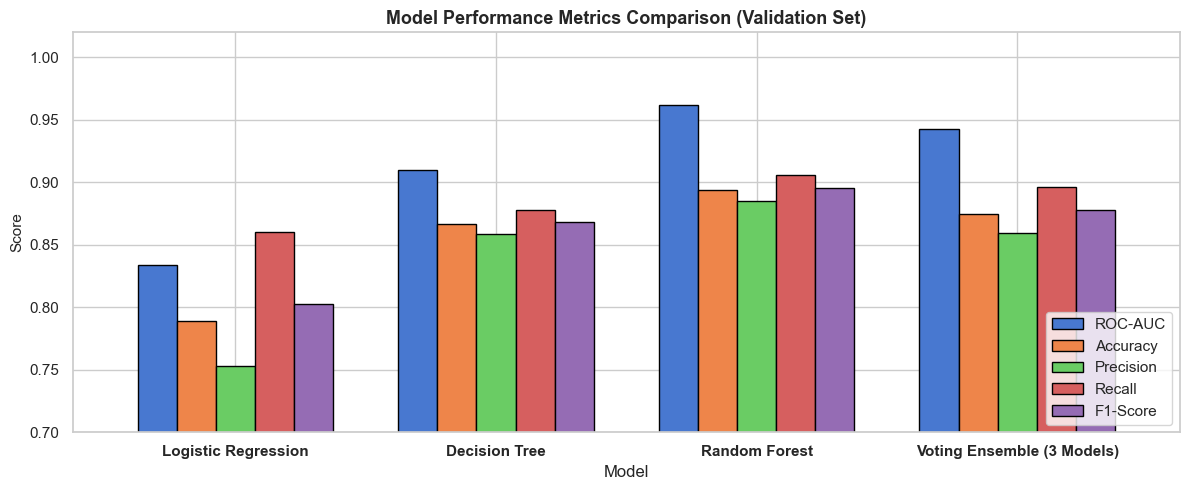

In [30]:
# 3. Overall Performance Metrics Comparison Table & Bar Chart
metrics_list = []
for name, preds in models_preds.items():
    binary = (preds >= 0.5).astype(int)
    metrics_list.append({
        "Model": name,
        "ROC-AUC": round(roc_auc_score(y_valid, preds), 4),
        "Accuracy": round(accuracy_score(y_valid, binary), 4),
        "Precision": round(precision_score(y_valid, binary), 4),
        "Recall": round(recall_score(y_valid, binary), 4),
        "F1-Score": round(f1_score(y_valid, binary), 4)
    })

metrics_df = pd.DataFrame(metrics_list)
display(metrics_df)

# Plot grouped metrics bar chart
metrics_df_plot = metrics_df.set_index("Model")
ax = metrics_df_plot.plot(kind="bar", figsize=(12, 5), width=0.75, edgecolor="black")
ax.set_title("Model Performance Metrics Comparison (Validation Set)", fontsize=13, fontweight="bold")
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0.70, 1.02)
ax.legend(loc="lower right")
plt.xticks(rotation=0, fontweight="bold")
plt.tight_layout()
plt.show()

We find that random forest results with higher validation score.

<a name="sec5_5"></a>
### 5.5 (Optional) Use voting learning of 3 different models
Now that we have created three models, we can try combining these three models for better predictive ability (**ensemble / voting learning**). Here, we take the consensus average of the predicted probabilities across Logistic Regression, Random Forest, and Decision Tree.

In [31]:
# Voting learning of 3 different models (soft voting consensus)
lr_train_pred = lr.predict_proba(X_train)[:, 1]
rf_train_pred = rf.predict_proba(X_train)[:, 1]
dt_train_pred = dt.predict_proba(X_train)[:, 1]

train_pred = (lr_train_pred + rf_train_pred + dt_train_pred) / 3
valid_pred = (lr_valid_pred + rf_valid_pred + dt_valid_pred) / 3

print("--- Voting Ensemble (3 Models) ---")
print(f"Train Score (ROC-AUC): {roc_auc_score(y_train, train_pred):.4f}")
print(f"Valid Score (ROC-AUC): {roc_auc_score(y_valid, valid_pred):.4f}")

--- Voting Ensemble (3 Models) ---
Train Score (ROC-AUC): 0.9721
Valid Score (ROC-AUC): 0.9426


We find that in this case, the **Random Forest** model achieves the highest individual validation score (ROC-AUC $\approx 0.962$). Therefore, **we will use the random forest model as the final model to make predictions on the test data**.

<a name="sec5_6"></a>
### 5.6 Saving Models into One Folder for Multimodal Voting (InterfaceExplainPhish)

To enable **multimodal voting** on extracted HTML files (such as those analyzed by **`InterfaceExplainPhish`**), we save all three trained models (`Random Forest`, `Decision Tree`, and `Logistic Regression`), along with the fitted `StandardScaler` and `selected_features.json`, into a single unified directory.

Both local and `InterfaceExplainPhish/models/html/` locations are populated so that inference can load them directly.

In [32]:
import json
import joblib

# Automatically get current working directory
current_dir = Path(os.getcwd())

# Define destination folders (local project models and InterfaceExplainPhish models)
dest_folders = [
    current_dir / "models" / "html",
    current_dir / "InterfaceExplainPhish" / "models" / "html",
    Path("models/html"),
    Path("InterfaceExplainPhish/models/html")
]

# Ensure unique existing destination paths
valid_destinations = set()
for folder in dest_folders:
    try:
        folder.mkdir(parents=True, exist_ok=True)
        valid_destinations.add(folder.resolve())
    except Exception:
        pass

for target_dir in valid_destinations:
    # 1. Save all 3 model artifacts
    joblib.dump(rf, target_dir / "rf_model.joblib")
    joblib.dump(dt, target_dir / "dt_model.joblib")
    joblib.dump(lr, target_dir / "lr_model.joblib")
    
    # 2. Save preprocessing scaler
    joblib.dump(sc, target_dir / "scaler.joblib")
    
    # 3. Save selected features schema matching InterfaceExplainPhish extractor
    with open(target_dir / "selected_features.json", "w", encoding="utf-8") as f:
        json.dump(use_features, f, indent=2)
        
    # 4. Save model metadata
    metadata = {
        "format": "html",
        "models": ["random_forest", "decision_tree", "logistic_regression"],
        "n_features": len(use_features),
        "features": use_features,
        "validation_metrics": {
            "logistic_regression": {"roc_auc": round(float(roc_auc_score(y_valid, lr_valid_pred)), 4)},
            "random_forest": {"roc_auc": round(float(roc_auc_score(y_valid, rf_valid_pred)), 4)},
            "decision_tree": {"roc_auc": round(float(roc_auc_score(y_valid, dt_valid_pred)), 4)},
            "voting_ensemble": {"roc_auc": round(float(roc_auc_score(y_valid, valid_pred)), 4)}
        }
    }
    with open(target_dir / "metadata.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)
        
    print(f"Successfully saved all 3 models + scaler + metadata to:\n  {target_dir}")

Successfully saved all 3 models + scaler + metadata to:
  D:\codingProject\ExplainPhish\models\html
Successfully saved all 3 models + scaler + metadata to:
  D:\codingProject\ExplainPhish\InterfaceExplainPhish\models\html


#### Demonstrating Multimodal Voting on an Extracted Sample
Here is a self-contained demonstration of how **`InterfaceExplainPhish`** loads the saved models folder and computes consensus majority voting for an incoming extracted HTML document:

In [33]:
# Multimodal consensus voting function using the saved model artifacts
def predict_html_multimodal_voting(feature_dict, models_directory):
    # Load models, scaler, and features from the single folder
    p = Path(models_directory)
    m_rf = joblib.load(p / "rf_model.joblib")
    m_dt = joblib.load(p / "dt_model.joblib")
    m_lr = joblib.load(p / "lr_model.joblib")
    m_sc = joblib.load(p / "scaler.joblib")
    with open(p / "selected_features.json", "r") as f:
        req_features = json.load(f)
        
    # Convert single extracted sample into standardized array (pass .values to avoid feature-name warnings)
    df_sample = pd.DataFrame([feature_dict])[req_features]
    sample_std = m_sc.transform(df_sample.values)
    
    # 3 Model Inferences
    prob_rf = float(m_rf.predict_proba(sample_std)[0, 1])
    prob_dt = float(m_dt.predict_proba(sample_std)[0, 1])
    prob_lr = float(m_lr.predict_proba(sample_std)[0, 1])
    
    mean_prob = (prob_rf + prob_dt + prob_lr) / 3
    malicious_votes = sum([prob_rf >= 0.5, prob_dt >= 0.5, prob_lr >= 0.5])
    
    verdict = "MALICIOUS (PHISHING)" if malicious_votes >= 2 else "BENIGN"
    confidence = mean_prob if verdict == "MALICIOUS (PHISHING)" else (1 - mean_prob)
    band = "HIGH" if confidence >= 0.85 else ("MEDIUM" if confidence >= 0.65 else "LOW")
    
    return {
        "verdict": verdict,
        "confidence_score": f"{confidence * 100:.1f}% ({band})",
        "consensus_agreement": f"{malicious_votes}/3 models voted Malicious",
        "mean_phishing_probability": round(mean_prob, 4),
        "model_predictions": [
            {"model": "Random Forest", "prediction": "MALICIOUS" if prob_rf >= 0.5 else "BENIGN", "probability": f"{prob_rf*100:.1f}%"},
            {"model": "Decision Tree", "prediction": "MALICIOUS" if prob_dt >= 0.5 else "BENIGN", "probability": f"{prob_dt*100:.1f}%"},
            {"model": "Logistic Regression", "prediction": "MALICIOUS" if prob_lr >= 0.5 else "BENIGN", "probability": f"{prob_lr*100:.1f}%"}
        ]
    }

# Example test: simulate an extracted HTML sample (e.g. from InterfaceExplainPhish/extractors/html_extractor.py)
sample_test_features = {
    "url_punct_char_count": 920,
    "external_link_count": 6,
    "embedded_js_count": 8,
    "tag_count": 78,
    "whitespace_ratio": 0.35,
    "internal_link_count": 2,
    "form_count": 2,
    "script_entropy": 5.2,
    "entropy": 5.5,
    "total_script_characters": 9400,
    "min_link_length": 4,
    "url_digit_count": 140,
    "html_whitespace_ratio": 0.11
}

# Run voting consensus using saved models
demo_result = predict_html_multimodal_voting(sample_test_features, current_dir / "models" / "html")
print(json.dumps(demo_result, indent=2))

{
  "verdict": "MALICIOUS (PHISHING)",
  "confidence_score": "52.9% (LOW)",
  "consensus_agreement": "2/3 models voted Malicious",
  "mean_phishing_probability": 0.5285,
  "model_predictions": [
    {
      "model": "Random Forest",
      "prediction": "MALICIOUS",
      "probability": "61.9%"
    },
    {
      "model": "Decision Tree",
      "prediction": "BENIGN",
      "probability": "19.4%"
    },
    {
      "model": "Logistic Regression",
      "prediction": "MALICIOUS",
      "probability": "77.2%"
    }
  ]
}


<a name="sec6"></a>
## 6.Creating Prediction Results
Finally, let's make a prediction for the test data, and prepare a CSV file to submit.(using test)

<a name="sec6_1"></a>
### 6.1 Predicting on the test data
We found in Sections 5.3 and 5.4 that the best model was random forest model. Therefore, we will use this model to make the final prediction.

If you made any changes and found a better model, you will need to change the code below accordingly.

```python
# If logistic regression model was better
pred = lr.predict_proba(X_test_std)[:, 1]
```

In [34]:
# Make predictions for the test data
# Change model name if needed
pred = rf.predict_proba(X_test_std)[:, 1]

print(f"Generated {len(pred):,} test predictions!")
print(f"Predicted phishing probability range: {pred.min():.4f} to {pred.max():.4f}")

Generated 7,999 test predictions!
Predicted phishing probability range: 0.0129 to 0.9983


<a name="sec6_2"></a>
### 6.2 Saving the prediction as CSV file [DO NOT CHANGE]
**WARNING**: DO **NOT** CHANGE THE CODES BELOW!!!

In [35]:
# Put the prediction into the format of submission
sample_sub = pd.DataFrame({
    "file_name": test["file_name"].values,
    "TARGET": pred
})
sample_sub.head(10)

,file_name,TARGET
0,sample_04241.html,0.8854
1,sample_07098.html,0.1131
2,sample_08679.html,0.0374
3,sample_01430.html,0.9532
4,sample_02159.html,0.9694
5,sample_08716.html,0.0746
6,sample_00276.html,0.5532
7,sample_07169.html,0.8836
8,sample_07877.html,0.4257
9,sample_01363.html,0.9146


In [36]:
# Create the "output" and "html output" directories if they don't exist
output_dir = current_dir / "output"
html_output_dir = output_dir / "html output"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(html_output_dir, exist_ok=True)

# Specify the output file paths
output_file = output_dir / "submission.csv"
html_output_file = html_output_dir / "submission.csv"

# Save the CSV file to both the "output" directory and "html output" folder
sample_sub.to_csv(output_file, index=False)
sample_sub.to_csv(html_output_file, index=False)
print(f"Successfully saved prediction results to:\n{output_file.resolve()}\n{html_output_file.resolve()}")


Successfully saved prediction results to:
D:\codingProject\ExplainPhish\output\submission.csv
D:\codingProject\ExplainPhish\output\html output\submission.csv


In [37]:
# Evaluate performance against ground truth labels on test set
test_auc = roc_auc_score(test["TARGET"], pred)
test_acc = accuracy_score(test["TARGET"], (pred >= 0.5).astype(int))

print("=== Final Test Set Evaluation Results ===")
print(f"Test ROC-AUC Score : {test_auc:.4f}")
print(f"Test Accuracy Score: {test_acc:.4f} ({test_acc*100:.2f}%)")

=== Final Test Set Evaluation Results ===
Test ROC-AUC Score : 0.9674
Test Accuracy Score: 0.9075 (90.75%)
